# Bölüm 1 — Veri hazırlığı ve keşif

In [1]:
import pandas as pd
import numpy as np

# Dosyaları yükleyelim
df_musteriler = pd.read_csv(r'veri\musteriler.csv')
df_araclar = pd.read_csv(r'veri\araclar.csv')
df_servis = pd.read_csv(r'veri\servis_kayitlari.csv')
df_feedback = pd.read_csv(r'veri\geri_bildirimler.csv')


In [2]:
# Veri setlerinin genel yapısını inceleyelim

dfs = {
    "Müşteriler": df_musteriler,
    "Araçlar": df_araclar,
    "Servis Kayıtları": df_servis,
    "Geri Bildirimler": df_feedback
}

for isim, df in dfs.items():
    print(f"\n{'='*60}")
    print(f"{isim}")
    print(f"{'='*60}")
    
    print(f"Satır sayısı : {df.shape[0]:,}")
    print(f"Sütun sayısı : {df.shape[1]}")
    
    print("\nSütunlar:")
    print(df.columns.tolist())
    
    print("\nVeri tipleri:")
    print(df.dtypes)
    
    print("\nEksik değerler:")
    print(df.isna().sum())


Müşteriler
Satır sayısı : 4,235
Sütun sayısı : 8

Sütunlar:
['musteri_id', 'sehir', 'musteri_tipi', 'dogum_yili', 'ilk_temas_tarihi', 'kayit_kanali', 'crm_musteri_durumu', 'son_iletisim_notu']

Veri tipleri:
musteri_id              int64
sehir                  object
musteri_tipi           object
dogum_yili            float64
ilk_temas_tarihi       object
kayit_kanali           object
crm_musteri_durumu     object
son_iletisim_notu      object
dtype: object

Eksik değerler:
musteri_id               0
sehir                    0
musteri_tipi             0
dogum_yili              97
ilk_temas_tarihi         0
kayit_kanali             0
crm_musteri_durumu       0
son_iletisim_notu     1531
dtype: int64

Araçlar
Satır sayısı : 4,786
Sütun sayısı : 8

Sütunlar:
['arac_id', 'musteri_id', 'marka', 'model', 'model_yili', 'satin_alma_tarihi', 'garanti_bitis_tarihi', 'ilk_km']

Veri tipleri:
arac_id                  int64
musteri_id               int64
marka                   object
model       

**Veri Seti İlk İnceleme ve Şema Bulguları:**

* **Boyutlar:** Müşteriler 4.235, Araçlar 4.786, Servis Kayıtları 32.770 ve Geri Bildirimler 640 kayıttan oluşuyor.
* **Veri tipleri:** Tarih alanlarının metin formatında olduğu görüldü. Analiz için tarih formatına dönüştürülecek.
* **Eksik değerler:** `memnuniyet_puani` ve `son_iletisim_notu` alanlarında daha fazla eksik değer bulunuyor. Ayrıca `dogum_yili` alanında 97, geri bildirim `metin` alanında 11 boş kayıt tespit edildi.


In [3]:
# Her tablonun ilk 5 satırını görelim

for isim, df in dfs.items():
    print(f"\n{'='*60}")
    print(f"{isim} - İlk 5 kayıt")
    print(f"{'='*60}")
    display(df.head())


Müşteriler - İlk 5 kayıt


,musteri_id,sehir,musteri_tipi,dogum_yili,ilk_temas_tarihi,kayit_kanali,crm_musteri_durumu,son_iletisim_notu
0,102288,Ankara,Bireysel,2002.0,2020-06-25,Bayi,Aktif,Kampanya bilgilendirmesi
1,103065,Bursa,Bireysel,1965.0,2017-06-13,Bayi,Aktif,Memnuniyet araması
2,103404,İstanbul,Bireysel,1999.0,2021-05-30,Bayi,Aktif,Kampanya bilgilendirmesi
3,102505,İstanbul,Bireysel,1999.0,2021-01-09,Bayi,Aktif,NaN
4,102599,Kocaeli,Bireysel,1993.0,2016-12-13,Bayi,Aktif,Memnuniyet araması



Araçlar - İlk 5 kayıt


,arac_id,musteri_id,marka,model,model_yili,satin_alma_tarihi,garanti_bitis_tarihi,ilk_km
0,500001,100001,Marka-A,A-Sedan,2013,2013-12-02,2018-12-01,9
1,500002,100002,Marka-C,C-Mini,2019,2019-05-10,2024-05-08,15
2,500003,100003,Marka-A,A-SUV,2017,2017-07-08,2022-07-07,0
3,500004,100004,Marka-B,B-Hatch,2023,2023-08-27,2026-08-26,25
4,500005,100005,Marka-A,A-Sedan,2014,2014-05-21,2017-05-20,47



Servis Kayıtları - İlk 5 kayıt


,kayit_id,arac_id,servis_tarihi,servis_tipi,servis_merkezi,km,tutar,memnuniyet_puani
0,21678,503213,2023-04-26 00:00:00,Periyodik Bakım,SM-Ankara1,501,5319.69,5.0
1,12553,501847,26/11/2023,Periyodik Bakım,SM-Ankara1,1465,9200.00,4.0
2,29838,504408,2025-03-24,Arıza Onarım,SM-Maslak,1221,17307.98,2.0
3,26597,503938,2025-11-05,Lastik/Balans,SM-Ankara1,2905,3686.55,4.0
4,28517,504221,09.05.2025,Periyodik Bakım,SM-Maslak,1881,5716.90,4.0



Geri Bildirimler - İlk 5 kayıt


,geri_bildirim_id,arac_id,tarih,kanal,metin
0,9001,500339,2025-01-26,Çağrı Merkezi,Mükemmel değildi ama beklentimin altında da ka...
1,9002,500075,2023-11-22,Google Yorum,"Servis temizdi ve ekip güler yüzlüydü, yalnızc..."
2,9003,502791,2023-06-25,Anket,NaN
3,9004,500867,2023-07-05,Google Yorum,"Randevu saatinde gittim ama iki saat bekledim,..."
4,9005,500154,2023-11-02,Google Yorum,Yedek araç verilmesi büyük kolaylık oldu.


**Örnek Veri İnceleme Bulguları:**

* **Tarih formatları:** `servis_tarihi` kolonunda farklı tarih formatları kullanıldığı görüldü.
* **Kesim tarihi sonrası kayıtlar:** `2025-06-30` sonrası servis kayıtları bulundu. Bu kayıtlar analiz dışında bırakılacaktır.
* **Boş geri bildirimler:** Geri bildirim alanında boş (`NaN`) kayıtlar olduğu görüldü.


In [4]:
# Sayısal değişkenlerin özeti
for isim, df in [("Müşteriler", df_musteriler), ("Araçlar", df_araclar), ("Servis Kayıtları", df_servis)]:
    print(f"\n{'='*60}")
    print(f"{isim} - Sayısal Değişken Özeti")
    print(f"{'='*60}")
    display(df.describe())


Müşteriler - Sayısal Değişken Özeti


,musteri_id,dogum_yili
count,4235.000000,4138.000000
mean,102100.868241,1979.309812
std,1212.306097,15.076013
min,100001.000000,1890.000000
25%,101051.500000,1967.000000
50%,102101.000000,1980.000000
75%,103148.500000,1992.000000
max,104200.000000,2021.000000



Araçlar - Sayısal Değişken Özeti


,arac_id,musteri_id,model_yili,ilk_km
count,4786.000000,4786.000000,4786.000000,4786.000000
mean,502393.500000,102097.907647,2018.963017,31.706435
std,1381.743524,1213.899640,3.739659,22.660746
min,500001.000000,100001.000000,2013.000000,0.000000
25%,501197.250000,101051.250000,2016.000000,14.000000
50%,502393.500000,102084.500000,2019.000000,31.000000
75%,503589.750000,103152.750000,2022.000000,47.000000
max,504786.000000,104200.000000,2025.000000,115.000000



Servis Kayıtları - Sayısal Değişken Özeti


,kayit_id,arac_id,km,tutar,memnuniyet_puani
count,32770.000000,32770.000000,32770.000000,3.277000e+04,25895.000000
mean,16240.077632,502399.619194,1264.101129,1.299948e+04,3.938714
std,9369.901322,1386.262332,709.738249,3.706398e+04,0.833885
min,1.000000,500001.000000,-2976.000000,-4.722259e+04,1.000000
25%,8127.250000,501200.000000,670.000000,7.431535e+03,3.000000
50%,16245.500000,502389.000000,1188.000000,9.905420e+03,4.000000
75%,24353.750000,503596.000000,1786.000000,1.316515e+04,5.000000
max,32460.000000,504786.000000,3938.000000,2.886854e+06,5.000000


**Tespit Edilen Bulgular:**

* **Negatif değerler:** Servis kayıtlarında -2.976 km ve -47.222 TL tutar tespit edildi. Bu değerler hatalı görünüyor.
* **Aşırı uç değer:** Servis faturasında 2,88 milyon TL'ye kadar çıkan bir değer görüldü.
* **Mantıksız doğum yılları:** 1890 ve 2021 gibi gerçekçi olmayan doğum yılları tespit edildi.


In [5]:
# 1. Eksi KM ve Eksi Tutar Sayısı
eksi_km_sayisi = (df_servis['km'] < 0).sum()
eksi_tutar_sayisi = (df_servis['tutar'] < 0).sum()

# 2. Mantıksız Yaşlar (Kesim tarihi 2025 olduğu için 2007 sonrası doğanlar < 18 yaş, 1925 öncesi > 100 yaş)
yas_hatali_sayisi = ((df_musteriler['dogum_yili'] > 2007) | (df_musteriler['dogum_yili'] < 1925)).sum()

print(f"Negatif KM kayıt sayısı: {eksi_km_sayisi}")
print(f"Negatif Tutar kayıt sayısı: {eksi_tutar_sayisi}")
print(f"Mantıksız Doğum Yılı kayıt sayısı (<18 veya >100 yaş): {yas_hatali_sayisi}")

Negatif KM kayıt sayısı: 42
Negatif Tutar kayıt sayısı: 150
Mantıksız Doğum Yılı kayıt sayısı (<18 veya >100 yaş): 18


**Tespit Edilen Veri Kalitesi Sorunları:**

* **42 negatif KM:** Fiziksel olarak mümkün olmadığı için veri giriş hatası olabilir.
* **150 negatif tutar:** İptal/iade veya hatalı faturalandırmadan kaynaklanıyor olabilir.
* **18 mantıksız doğum yılı:** 18 yaş altı veya 100 yaş üstü müşteri kayıtları tespit edildi.

*Bu kayıtlar veri temizleme aşamasında değerlendirilecektir.*

In [6]:
# ============================================================
#  ID ve tablo ilişkilerinin kontrolü
# ============================================================

print("MÜŞTERİ ID KONTROLÜ")
print("-" * 50)

print("Toplam müşteri kaydı:", len(df_musteriler))
print("Benzersiz müşteri ID:", df_musteriler["musteri_id"].nunique())
print(
    "Tekrarlanan müşteri ID sayısı:",
    df_musteriler["musteri_id"].duplicated().sum()
)


print("\nARAÇ ID KONTROLÜ")
print("-" * 50)

print("Toplam araç kaydı:", len(df_araclar))
print("Benzersiz araç ID:", df_araclar["arac_id"].nunique())
print(
    "Tekrarlanan araç ID sayısı:",
    df_araclar["arac_id"].duplicated().sum()
)


print("\nSERVİS KAYDI ID KONTROLÜ")
print("-" * 50)

print("Toplam servis kaydı:", len(df_servis))
print("Benzersiz kayıt ID:", df_servis["kayit_id"].nunique())
print(
    "Tekrarlanan kayıt ID sayısı:",
    df_servis["kayit_id"].duplicated().sum()
)


print("\nGERİ BİLDİRİM ID KONTROLÜ")
print("-" * 50)

print("Toplam geri bildirim:", len(df_feedback))
print(
    "Benzersiz geri bildirim ID:",
    df_feedback["geri_bildirim_id"].nunique()
)
print(
    "Tekrarlanan geri bildirim ID sayısı:",
    df_feedback["geri_bildirim_id"].duplicated().sum()
)

MÜŞTERİ ID KONTROLÜ
--------------------------------------------------
Toplam müşteri kaydı: 4235
Benzersiz müşteri ID: 4200
Tekrarlanan müşteri ID sayısı: 35

ARAÇ ID KONTROLÜ
--------------------------------------------------
Toplam araç kaydı: 4786
Benzersiz araç ID: 4786
Tekrarlanan araç ID sayısı: 0

SERVİS KAYDI ID KONTROLÜ
--------------------------------------------------
Toplam servis kaydı: 32770
Benzersiz kayıt ID: 32460
Tekrarlanan kayıt ID sayısı: 310

GERİ BİLDİRİM ID KONTROLÜ
--------------------------------------------------
Toplam geri bildirim: 640
Benzersiz geri bildirim ID: 640
Tekrarlanan geri bildirim ID sayısı: 0


**ID Kontrolü Bulguları:**

* **35 tekrarlanan müşteri ID:** `musteri_id` alanında 35 tekrar bulundu. Birleştirme öncesinde kontrol edilmesi gerekiyor.
* **310 tekrarlanan servis ID:** `kayit_id` alanında 310 tekrar bulundu. Bu kayıtlar ayrıca incelenecek.
* Araç ve Geri Bildirim tablolarında ID tekrarı bulunmadı.


In [7]:
# ============================================================
# TABLOLAR ARASI İLİŞKİ KONTROLÜ
# ============================================================

# Araçların bağlı olduğu müşteri ID'leri
arac_musteri_ids = set(df_araclar["musteri_id"])

# Müşteri tablosunda bulunmayan müşteri ID'sine bağlı araçlar
eksik_musteri_baglantisi = df_araclar[
    ~df_araclar["musteri_id"].isin(df_musteriler["musteri_id"])
]

print("Müşteri tablosunda bulunmayan müşteriye bağlı araç sayısı:",
      len(eksik_musteri_baglantisi))


# Servis kayıtlarında olup araçlar tablosunda bulunmayan araçlar
eksik_arac_baglantisi = df_servis[
    ~df_servis["arac_id"].isin(df_araclar["arac_id"])
]

print(
    "Araçlar tablosunda bulunmayan araca ait servis kaydı:",
    len(eksik_arac_baglantisi)
)


# Geri bildirimlerde olup araçlar tablosunda bulunmayan araçlar
eksik_feedback_arac = df_feedback[
    ~df_feedback["arac_id"].isin(df_araclar["arac_id"])
]

print(
    "Araçlar tablosunda bulunmayan araca ait geri bildirim:",
    len(eksik_feedback_arac)
)

Müşteri tablosunda bulunmayan müşteriye bağlı araç sayısı: 0
Araçlar tablosunda bulunmayan araca ait servis kaydı: 0
Araçlar tablosunda bulunmayan araca ait geri bildirim: 0


In [8]:
# ============================================================
# MÜŞTERİ BAŞINA ARAÇ SAYISI
# ============================================================

arac_sayilari = (
    df_araclar
    .groupby("musteri_id")
    .size()
    .reset_index(name="arac_sayisi")
)

print(arac_sayilari["arac_sayisi"].describe())

print("\nAraç sayısına göre müşteri dağılımı:")
print(arac_sayilari["arac_sayisi"].value_counts().sort_index())

count    4200.000000
mean        1.139524
std         0.346534
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         2.000000
Name: arac_sayisi, dtype: float64

Araç sayısına göre müşteri dağılımı:
arac_sayisi
1    3614
2     586
Name: count, dtype: int64


**Müşteri Başına Araç Dağılımı Bulguları:** 
* 3.614 müşterinin 1 aracı, 586 müşterinin 2 aracı bulunmaktadır (Toplam 4.200 tekil müşteri).
* 1 müşterinin birden fazla aracı olması, musteriler ve araclar tabloları doğrudan birleştirildiğinde bazı müşterilerin birden fazla satırda yer almasına yol açar. Bu nedenle müşteri seviyesine indirgeme (aggregation) zorunludur.

In [9]:
df_servis

,kayit_id,arac_id,servis_tarihi,servis_tipi,servis_merkezi,km,tutar,memnuniyet_puani
0,21678,503213,2023-04-26 00:00:00,Periyodik Bakım,SM-Ankara1,501,5319.69,5.0
1,12553,501847,26/11/2023,Periyodik Bakım,SM-Ankara1,1465,9200.00,4.0
2,29838,504408,2025-03-24,Arıza Onarım,SM-Maslak,1221,17307.98,2.0
3,26597,503938,2025-11-05,Lastik/Balans,SM-Ankara1,2905,3686.55,4.0
4,28517,504221,09.05.2025,Periyodik Bakım,SM-Maslak,1881,5716.90,4.0
...,...,...,...,...,...,...,...,...
32765,4024,500586,2025-12-02,Arıza Onarım,SM-Maslak,2625,22726.68,4.0
32766,32082,504731,2023-09-16,Periyodik Bakım,SM-Antalya1,1232,11018.53,4.0
32767,7260,501079,20/02/2025,Kaporta/Boya,SM-Kadıköy,386,33021.07,4.0
32768,21585,503198,2024-11-14,Lastik/Balans,SM-Maslak,1236,11477.14,3.0


In [10]:
# 1. Tarihleri datetime formatına getirelim
df_servis['servis_tarihi'] = pd.to_datetime(df_servis['servis_tarihi'], format='mixed', errors='coerce')
kesim_tarihi = pd.to_datetime('2025-06-30')

In [11]:
print("Tarih dönüşümü sonrası eksik tarih sayısı:",
      df_servis['servis_tarihi'].isna().sum())

Tarih dönüşümü sonrası eksik tarih sayısı: 0


### Tarih Alanının Standardizasyonu

`servis_tarihi` farklı tarih formatlarında tutulduğu için tarih bazlı işlemlerden önce `datetime` formatına dönüştürülmüştür. Kesim tarihi 30 Haziran 2025 olarak belirlenmiş ve gözlem ile hedef dönemlerinin birbirinden ayrılması amaçlanmıştır.

In [12]:
# 2. GÖZLEM PENCERESİ: Sadece 2025-06-30 ve öncesi servis kayıtları
df_servis_gozlem = df_servis[df_servis['servis_tarihi'] <= kesim_tarihi].copy()

In [13]:
print("Gözlem Penceresi (Geçmiş) Servis Kaydı Sayısı:", len(df_servis_gozlem))
print("Hedef Penceresi (Gelecek) Servis Kaydı Sayısı:", (df_servis['servis_tarihi'] > kesim_tarihi).sum())

Gözlem Penceresi (Geçmiş) Servis Kaydı Sayısı: 25264
Hedef Penceresi (Gelecek) Servis Kaydı Sayısı: 7506


Toplam: 25.264 + 7.506 = **32.770**. Böylece hiçbir satır kaybolmadı ve veri istediğimiz şekilde iki gruba ayrıldı.


In [14]:
# 3.Servis kayıtlarına musteri_id bilgisini araçlar üzerinden ekleyelim
df_servis_musteri = pd.merge(
    df_servis_gozlem,
    df_araclar[['arac_id', 'musteri_id']],
    on='arac_id',
    how='inner'
)

In [15]:
print(f"Gözlem dönemindeki toplam servis kaydı : {len(df_servis_gozlem)}")
print(f"Müşteri ile eşleşen servis kaydı      : {len(df_servis_musteri)}")
print(f"Analiz edilecek tekil müşteri sayısı   : {df_servis_musteri['musteri_id'].nunique()}")

Gözlem dönemindeki toplam servis kaydı : 25264
Müşteri ile eşleşen servis kaydı      : 25264
Analiz edilecek tekil müşteri sayısı   : 3971


**Gözlem Penceresi ve Popülasyon Eşleşmesi:**
* 2025-06-30 öncesine ait 25.264 servis kaydının tamamı araç ve müşteriyle eksiksiz eşleşmiştir.
* Modelimizin ana popülasyonu 3.971 tekil müşteriden oluşmaktadır.

In [16]:
# Gözlem verisindeki Tekrarlanan servis kayıtlarını kontrol edelim
print("Gözlem verisinde aynı kayit_id tekrar sayısı:", df_servis_musteri['kayit_id'].duplicated().sum())
print("Gözlem verisinde birebir aynı (tüm sütunları eşit) kopya satır sayısı:", df_servis_musteri.duplicated().sum())

Gözlem verisinde aynı kayit_id tekrar sayısı: 247
Gözlem verisinde birebir aynı (tüm sütunları eşit) kopya satır sayısı: 247


**Tekrarlanan Servis Kayıtları:**

* 25.264 servis kaydının 247 tanesinin birebir tekrarlandığı görüldü.
* Frekans ve ciro hesaplarının yanlış sonuç vermemesi için bu kayıtlar silinecek.


In [17]:
# 247 adet birebir kopya satırı siliyoruz
df_servis_musteri_temiz = df_servis_musteri.drop_duplicates().copy()

print("Kopya silinmeden önceki servis sayısı :", len(df_servis_musteri))
print("Kopya silindikten sonraki servis sayısı:", len(df_servis_musteri_temiz))
print("Silinen kopya sayısı                   :", len(df_servis_musteri) - len(df_servis_musteri_temiz))

Kopya silinmeden önceki servis sayısı : 25264
Kopya silindikten sonraki servis sayısı: 25017
Silinen kopya sayısı                   : 247


### Tekrarlanan Servis Kayıtlarının Temizlenmesi

Gözlem dönemindeki 25.264 servis kaydının 247 tanesinin birebir tekrarlandığı görüldü. Bu kayıtlar ayrı servis işlemleri olarak değerlendirilmedi ve analizden çıkarıldı. Böylece aynı işlemin birden fazla sayılarak `frequency` ve `monetary` değerlerini artırması önlendi. Temizleme sonrasında 25.017 servis kaydı kaldı.


In [18]:
# Temiz servis verisinde negatif tutar ve km sayıları
eksi_tutar_sayisi = (df_servis_musteri_temiz['tutar'] < 0).sum()
eksi_km_sayisi = (df_servis_musteri_temiz['km'] < 0).sum()

print("Geçmiş servislerde negatif tutar sayısı:", eksi_tutar_sayisi)
print("Geçmiş servislerde negatif KM sayısı   :", eksi_km_sayisi)

Geçmiş servislerde negatif tutar sayısı: 118
Geçmiş servislerde negatif KM sayısı   : 26


In [19]:
# negatif tutar kontrolu
negatif_tutarlar = df_servis_musteri_temiz[
    df_servis_musteri_temiz['tutar'] < 0
].copy()

display(
    negatif_tutarlar[
        ['kayit_id', 'musteri_id', 'arac_id', 'servis_tarihi',
         'servis_tipi', 'servis_merkezi', 'km', 'tutar']
    ].sort_values('tutar').head(20)
)

,kayit_id,musteri_id,arac_id,servis_tarihi,servis_tipi,servis_merkezi,km,tutar
12522,1874,100237,500276,2023-05-16,Kaporta/Boya,SM-Maslak,625,-47222.59
8179,20219,102624,503000,2022-02-02,Kaporta/Boya,SM-Ankara1,334,-44240.88
24081,7481,100974,501110,2022-04-15,Arıza Onarım,SM-Ankara1,296,-40082.47
1051,23007,102983,503401,2025-03-10,Arıza Onarım,SM-Maslak,1969,-38788.45
10824,5687,100739,500841,2024-10-01,Kaporta/Boya,SM-Bursa1,1284,-36733.94
13667,12365,101594,501818,2022-06-15,Arıza Onarım,SM-Maslak,414,-36044.76
24797,3735,100472,500544,2024-12-27,Kaporta/Boya,SM-Bursa1,1327,-33664.65
15879,23875,103094,503525,2022-11-03,Arıza Onarım,SM-Maslak,744,-30543.42
23165,21805,102830,503232,2023-07-15,Kaporta/Boya,SM-Kadıköy,1384,-27362.66
1018,5839,100757,500863,2025-02-11,Arıza Onarım,SM-Maslak,1402,-27263.46


In [20]:
print(
    negatif_tutarlar['servis_tipi']
    .value_counts(dropna=False)
)

servis_tipi
Periyodik Bakım    75
Arıza Onarım       21
Lastik/Balans      11
Kaporta/Boya       11
Name: count, dtype: int64


In [21]:
df_servis_musteri_temiz.groupby(
    df_servis_musteri_temiz['tutar'] < 0
)['tutar'].agg(
    adet='count',
    min='min',
    max='max',
    ortalama='mean',
    toplam='sum'
)

,adet,min,max,ortalama,toplam
tutar,,,,,
False,24899,0.00,2.886854e+06,13252.894302,3.299838e+08
True,118,-47222.59,-2.256780e+03,-12467.796780,-1.471200e+06


### Negatif Tutarların Değerlendirilmesi
* Gözlem dönemindeki 25.017 servis kaydının 118'inde (%0,47) negatif `tutar` değeri tespit edilmiştir. Toplam etkisi -1,47 milyon TL olup genel cironun (%0,45) çok küçük bir kısmıdır.
* Negatif kayıtlar farklı servis tiplerinde (başta Periyodik Bakım olmak üzere) görülmekte olup, bunların muhasebe iadesi, garanti dekontu veya veri girişi hatası olup olmadığı mevcut veri sözlüğünden kesin olarak doğrulanamamaktadır.
* **Karar:** Doğrulanmamış bir varsayımla veriye müdahale edilmemiş, net harcamayı yansıtması amacıyla negatif tutarlar RFM hesaplamasında korunmuştur. Bu durum, modelin bir sınırlılığı ve iş birimiyle teyit edilmesi gereken bir veri kalitesi maddesi olarak not edilmiştir.

In [22]:
# negatif KM incelemesi
negatif_kmler = df_servis_musteri_temiz[
    df_servis_musteri_temiz['km'] < 0
].copy()

display(
    negatif_kmler[
        ['kayit_id', 'musteri_id', 'arac_id', 'servis_tarihi',
         'servis_tipi', 'servis_merkezi', 'km', 'tutar']
    ].sort_values('km').head(20)
)

,kayit_id,musteri_id,arac_id,servis_tarihi,servis_tipi,servis_merkezi,km,tutar
17150,4961,100632,500724,2025-06-16,Periyodik Bakım,SM-Antalya1,-2976,12321.20
21932,18622,102411,502762,2025-04-10,Kaporta/Boya,SM-Maslak,-2761,19594.14
12936,31849,104122,504697,2025-05-01,Periyodik Bakım,SM-Kadıköy,-2285,5984.59
7988,23041,102988,503406,2025-01-19,Periyodik Bakım,SM-Maslak,-1911,9842.69
11956,797,100104,500121,2024-06-20,Periyodik Bakım,SM-Kadıköy,-1857,11009.18
12161,26258,103410,503883,2025-05-20,Lastik/Balans,SM-Ankara1,-1600,7628.33
2310,10442,101359,501544,2024-05-09,Periyodik Bakım,SM-Kadıköy,-1523,8491.36
13783,29447,103827,504356,2025-02-22,Periyodik Bakım,SM-Maslak,-1518,11405.90
3454,8873,101157,501315,2024-02-17,Periyodik Bakım,SM-Kadıköy,-1477,7092.27
20458,13975,101793,502049,2025-06-11,Periyodik Bakım,SM-Maslak,-1420,11739.80


In [23]:
print(
    negatif_kmler['servis_tipi']
    .value_counts(dropna=False)
)

servis_tipi
Periyodik Bakım    15
Arıza Onarım        6
Lastik/Balans       3
Kaporta/Boya        2
Name: count, dtype: int64


In [24]:
df_servis_musteri_temiz.groupby(
    df_servis_musteri_temiz['tutar'] < 0
)['tutar'].agg(
    adet='count',
    min='min',
    max='max',
    ortalama='mean',
    toplam='sum'
)

,adet,min,max,ortalama,toplam
tutar,,,,,
False,24899,0.00,2.886854e+06,13252.894302,3.299838e+08
True,118,-47222.59,-2.256780e+03,-12467.796780,-1.471200e+06


In [25]:
# KM değerlerinin genel dağılımını kontrol edelim

print("Negatif KM sayısı :", (df_servis_musteri_temiz['km'] < 0).sum())
print("Sıfır KM sayısı   :", (df_servis_musteri_temiz['km'] == 0).sum())
print("Pozitif KM sayısı :", (df_servis_musteri_temiz['km'] > 0).sum())

print("\nKM özeti:")
print(df_servis_musteri_temiz['km'].describe())

Negatif KM sayısı : 26
Sıfır KM sayısı   : 0
Pozitif KM sayısı : 24991

KM özeti:
count    25017.000000
mean      1065.468681
std        573.078132
min      -2976.000000
25%        587.000000
50%       1012.000000
75%       1489.000000
max       3413.000000
Name: km, dtype: float64


In [26]:
# Negatif KM değerleri işaret hatası olarak değerlendirilerek mutlak değerleri alınmıştır.
df_servis_musteri_temiz['km'] = df_servis_musteri_temiz['km'].abs()
print(
    "Düzeltme sonrası negatif KM sayısı:",
    (df_servis_musteri_temiz['km'] < 0).sum()
)

Düzeltme sonrası negatif KM sayısı: 0


**Negatif KM Değerlerinin Analizi:**

* 25.017 kaydın 26'sında negatif KM değeri bulundu.
* Negatif değerlerin mutlak değerlerinin normal KM değerleriyle uyumlu olduğu görüldü.
* Bu nedenle değerlerin sistemsel bir hata kodundan ziyade veri girişinden kaynaklandığı düşünüldü.
* **Karar:** 26 kayıt silinmedi, `abs()` kullanılarak KM değerleri pozitife çevrildi.

## BÖLÜM 1.1 — ANALİZ TABLOSU VE RFM HESAPLAMA

In [27]:
# 1. RFM Metriklerini Hesaplama
kesim_tarihi = pd.to_datetime('2025-06-30')

rfm = df_servis_musteri_temiz.groupby('musteri_id').agg(
    son_servis_tarihi=('servis_tarihi', 'max'),
    frequency=('kayit_id', 'count'),       # Ziyaret sayısı
    monetary=('tutar', 'sum')              # Net harcama
).reset_index()

# Recency (Kesim tarihinden son servise kadar geçen gün sayısı)
rfm['recency'] = (kesim_tarihi - rfm['son_servis_tarihi']).dt.days
rfm.drop('son_servis_tarihi', axis=1, inplace=True)

# 2. Müşteri Başına Araç Sayısı (Aggregation)
arac_sayisi_df = df_araclar.groupby('musteri_id').agg(
    arac_sayisi=('arac_id', 'count')
).reset_index()

#3. Müşteri Tablosundaki Tekrarlanan Kayıtların Düzeltilmesi
df_musteriler_tekil = df_musteriler.drop_duplicates(subset=['musteri_id'], keep='last').copy()

# 4. Popülasyon ile Nihai Birleştirme (2025-06-30 öncesi servise gelen 3.971 müşteri)
df_analiz = pd.merge(rfm, df_musteriler_tekil, on='musteri_id', how='inner')
df_analiz = pd.merge(df_analiz, arac_sayisi_df, on='musteri_id', how='left')

print("=== BÖLÜM 1.1 BAŞARIYLA TAMAMLANDI ===")
print(f"Oluşturulan Tablo Boyutu (Satır, Sütun) : {df_analiz.shape}")
print(f"Popülasyondaki Tekil Müşteri Sayısı       : {df_analiz['musteri_id'].nunique()}")

display(df_analiz[['musteri_id', 'recency', 'frequency', 'monetary', 'arac_sayisi']].head(10))

=== BÖLÜM 1.1 BAŞARIYLA TAMAMLANDI ===
Oluşturulan Tablo Boyutu (Satır, Sütun) : (3971, 12)
Popülasyondaki Tekil Müşteri Sayısı       : 3971


,musteri_id,recency,frequency,monetary,arac_sayisi
0,100001,55,5,49051.54,1
1,100002,56,11,70055.31,1
2,100003,342,6,55720.83,1
3,100004,257,2,9768.39,1
4,100005,241,4,53324.25,1
5,100006,189,5,48352.20,1
6,100007,118,10,112641.36,2
7,100008,74,6,56290.74,1
8,100009,191,5,60910.10,1
9,100010,96,9,109795.64,1


### Bölüm 1.1 Tamamlandı — Analiz Tablosu Özeti

* **Popülasyon:** 2025-06-30 öncesinde en az 1 servis kaydı bulunan 3.971 farklı müşteri analize dahil edildi.
* **Metrikler:** Her müşteri için `recency` (gün), `frequency` (adet) ve `monetary` (TL) hesaplandı.
* **Müşteri başına araç:** Birden fazla aracı olan müşteriler için `arac_sayisi` hesaplanarak tabloya eklendi. Böylece müşterilerin birden fazla satırda oluşması engellendi.


## BÖLÜM 1.2 — Veri kalitesi

### 1) Doğum Yılı Anomalileri ve Yaş Değişkeni

In [28]:
# 1. Doğum yılı eksik olanların müşteri tipi (Bireysel mi, Kurumsal mı?)
print("Doğum yılı boş olan müşterilerin tipleri:")
print(df_analiz[df_analiz['dogum_yili'].isna()]['musteri_tipi'].value_counts())

Doğum yılı boş olan müşterilerin tipleri:
musteri_tipi
Bireysel    69
Kurumsal    19
Name: count, dtype: int64


In [29]:
# 2. Mantıksız doğum yılları (1925 öncesi >100 yaş, 2007 sonrası <18 yaş)
hatali_dogum_yillari = df_analiz[
    (df_analiz['dogum_yili'] < 1925) | (df_analiz['dogum_yili'] > 2007)
]

print(f"\nAnaliz tablosundaki mantıksız doğum yılı sayısı: {len(hatali_dogum_yillari)}")
print("Tespit edilen mantıksız yıllar:", hatali_dogum_yillari['dogum_yili'].tolist())


Analiz tablosundaki mantıksız doğum yılı sayısı: 16
Tespit edilen mantıksız yıllar: [2021.0, 2021.0, 1890.0, 1890.0, 1890.0, 2021.0, 2021.0, 1890.0, 1890.0, 1890.0, 1890.0, 2021.0, 2021.0, 1890.0, 2021.0, 2021.0]


In [30]:
print(
    hatali_dogum_yillari['musteri_tipi']
    .value_counts()
)

musteri_tipi
Bireysel    12
Kurumsal     4
Name: count, dtype: int64


In [31]:
print(
    hatali_dogum_yillari[
        ['musteri_id', 'musteri_tipi', 'dogum_yili']
    ].sort_values(['dogum_yili', 'musteri_tipi'])
)

      musteri_id musteri_tipi  dogum_yili
1052      101114     Bireysel      1890.0
1138      101206     Bireysel      1890.0
1525      101611     Bireysel      1890.0
1735      101828     Bireysel      1890.0
1972      102071     Bireysel      1890.0
3296      103484     Bireysel      1890.0
1039      101100     Kurumsal      1890.0
1658      101748     Kurumsal      1890.0
440       100466     Bireysel      2021.0
631       100666     Bireysel      2021.0
1304      101381     Bireysel      2021.0
1477      101562     Bireysel      2021.0
3286      103473     Bireysel      2021.0
3508      103710     Bireysel      2021.0
2627      102772     Kurumsal      2021.0
3529      103733     Kurumsal      2021.0


In [32]:
# 1. Hatalı doğum yıllarını (1890 ve 2021) bilinmeyen (NaN) olarak işaretliyoruz
df_analiz.loc[(df_analiz['dogum_yili'] < 1925) | (df_analiz['dogum_yili'] > 2007), 'dogum_yili'] = np.nan

# 2. 2025 yılına göre mantıklı 'yas' değişkeni üretiyoruz
df_analiz['yas'] = 2025 - df_analiz['dogum_yili']

print("Düzeltme sonrası Yaş (yas) özeti:")
print(df_analiz['yas'].describe())

Düzeltme sonrası Yaş (yas) özeti:
count    3867.000000
mean       45.690716
std        14.425954
min        21.000000
25%        33.000000
50%        46.000000
75%        58.000000
max        70.000000
Name: yas, dtype: float64


**Doğum Yılı Anomalileri ve Yaş Değişkeni:**

* 16 müşteride 1890 ve 2021 gibi mantıksız doğum yılları bulundu.
* Bu kayıtlar silinmek yerine `NaN` olarak işaretlendi ve 2025 yılı baz alınarak `yas` değişkeni oluşturuldu.
* Düzeltme sonrasında yaşlar 21–70 aralığına geldi. Ortalama yaş **45,7** oldu.


### 2) Analiz Tablosundaki Eksik Değerlerin (NaN) Tespiti ve İncelenmesi

In [33]:
# Analiz tablomuzdaki tüm eksik değerlerin (NaN) dökümü
print("--- ANALİZ TABLOSUNDAKİ EKSİK VERİLER ---")
eksikler = df_analiz.isna().sum()[df_analiz.isna().sum() > 0]
print(eksikler)

--- ANALİZ TABLOSUNDAKİ EKSİK VERİLER ---
dogum_yili            104
son_iletisim_notu    1431
yas                   104
dtype: int64


### Eksik Değerlerin Yönetimi

* **`yas`:** Kurumsal müşterilerde doğum yılı olmadığı için 104 eksik değer `NaN` olarak bırakıldı. Eksik değerleri ortalamayla doldurup dağılımı değiştirmemeyi tercih ettik.
* **`son_iletisim_notu`:** Veri sözlüğünde bu alanın tarihsiz bir serbest not olduğu belirtilmiş. Boş olmasının iletişim kurulmadığı anlamına geldiğine dair kesin bir kanıt olmadığı için 1.431 eksik değer `NaN` olarak bırakıldı.


In [34]:
print("son_iletisim_notu boş değer sayısı (NaN korundu):", df_analiz['son_iletisim_notu'].isna().sum())


son_iletisim_notu boş değer sayısı (NaN korundu): 1431


### 3) Kilometre ve Fatura Tutarı Anomalileri (Negatif ve Uç Değerler)

In [35]:
# Kilometre ve Tutar kararlarının son durum kontrolü
print("--- GÖZLEM DÖNEMİ SERVİS VERİSİ GÜNCEL DURUMU ---")
print(f"Toplam servis kaydı              : {len(df_servis_musteri_temiz):,}")
print(f"Negatif KM sayısı (abs uygulandı) : {(df_servis_musteri_temiz['km'] < 0).sum()}")
print(f"Negatif Tutar sayısı (korundu)    : {(df_servis_musteri_temiz['tutar'] < 0).sum()}")
print(f"Maksimum Tutar (Uç Değer)         : {df_servis_musteri_temiz['tutar'].max():,.2f} TL")
print(f"Maksimum KM                       : {df_servis_musteri_temiz['km'].max():,} km")

--- GÖZLEM DÖNEMİ SERVİS VERİSİ GÜNCEL DURUMU ---
Toplam servis kaydı              : 25,017
Negatif KM sayısı (abs uygulandı) : 0
Negatif Tutar sayısı (korundu)    : 118
Maksimum Tutar (Uç Değer)         : 2,886,854.22 TL
Maksimum KM                       : 3,413 km


Bu adımda servis kayıtlarındaki fiziksel ve finansal anomaliler değerlendirilmiş ve şu kararlar uygulanmıştır:
1. **Negatif KM (26 Adet):** Fiziksel olarak araç geriye gidemeyeceğinden ve değerlerin büyüklüğü normal KM aralığına uyduğundan klavye hatası kabul edilip mutlak değeri (`abs()`) alınmıştır.
2. **Negatif Fatura (118 Adet):** İade veya finansal düzeltme olabileceği için doğrulanmamış varsayımla silinmemiş, net harcamayı yansıtacak şekilde korunmuştur.

### Bölüm 1.2 — Veri Kalitesi Bulguları ve Kararlar

*Not: Tekrarlanan kayıt, KM ve tutar kontrolleri Bölüm 1.1'e geçmeden önce yapıldı. Bu kontrollerle RFM tablosunun doğru veriler üzerinden oluşturulması sağlandı.*

#### 1. Doğum Yılı Anomalileri ve Yaş Değişkeni

* **Ne bulduk?** 16 müşteride 1890 ve 2021 gibi mantıksız doğum yılları, 88 müşteride ise eksik doğum yılı bulundu.
* **Ne yaptık?** Hatalı doğum yılları `NaN` yapıldı. 2025 baz alınarak `yas` değişkeni oluşturuldu ve yaşlar 21–70 aralığına geldi. Eksik değerler yapay olarak doldurulmadı.
* **Neden bu kararı verdik?** 135 yaşında veya 4 yaşında araç sahibi olamayacağı için hata giderildi. kurumsal firmalara yapay yaş atamamak ve bireysel dağılımı bozmamak için eksikler NaN olarak bırakıldı.

---

#### 2. Eksik Gözlemler (`son_iletisim_notu` ve `memnuniyet_puani`)
* **Ne Bulduk?** `son_iletisim_notu` alanında 1.431 adet eksik değer, `servis_kayitlari` tablosunda ise 6.875 adet boş `memnuniyet_puani` tespit edildi.
* **Ne Yaptık?** İki alan da ortalama veya yapay bir kategoriyle doldurulmadı, `NaN` olarak korundu.
* **Neden Bu Kararı Verdik?** Veri sözlüğünde bu alanların tarihsiz olduğu ve anketin zorunlu olmadığı belirtilmiştir. "İletişim kurulmadı" veya "memnuniyeti ortalamadır (3.94)" gibi doğrulanmamış varsayımlar üretip modeli sahte bilgiyle beslememek (ve zaman sızıntısını önlemek) için eksiklikler olduğu gibi bırakılmıştır.


---

#### 3. Negatif Kilometre ve Negatif Fatura Tutarları
* **Ne Bulduk?** 26 servis kaydında negatif kilometre (Min: -2976) ve 118 kayıtta negatif tutar (Toplam -1,47M TL) tespit edildi.
* **Ne Yaptık?** Negatif KM değerlerinin abs() ile mutlak değeri alındı. Negatif tutarlara ise müdahale edilmedi ve toplam hesaba dahil edildi
* **Neden Bu Kararı Verdik?** KM değerlerinin büyüklüğü normal değerlerle uyumlu olduğu için bunun veri girişindeki eksi işaretinden kaynaklandığı düşünüldü. Negatif tutarların ise iade veya iptal olma ihtimali bulunduğundan, kesin bir bilgi olmadan değiştirilmedi.

## BÖLÜM 1.3 — Keşifsel Analiz

### 1) Hedef Değişkenin (Churn) Üretilmesi
* **Kural:** Hedef penceresinde (2025-07-01 ile 2026-06-30 arası) en az 1 kez servise gelen müşteriler `churn = 0` (kalan), hiç gelmeyen müşteriler ise `churn = 1` (terk eden) olarak etiketlenmiştir.

In [36]:
# 1. Hedef Penceresi Filtresi (2025-07-01 ile 2026-06-30)
hedef_baslangic = pd.to_datetime('2025-07-01')
hedef_bitis = pd.to_datetime('2026-06-30')

df_servis_hedef = df_servis[
    (df_servis['servis_tarihi'] >= hedef_baslangic) & 
    (df_servis['servis_tarihi'] <= hedef_bitis)
].copy()

# 2. Hedef döneminde gelen müşterileri buluyoruz
df_hedef_musteri = pd.merge(
    df_servis_hedef, 
    df_araclar[['arac_id', 'musteri_id']], 
    on='arac_id', 
    how='inner'
)
gelen_musteriler = set(df_hedef_musteri['musteri_id'].unique())

# 3. Churn Etiketini Atama (Geldiyse 0, Gelmediyse 1)
df_analiz['churn'] = df_analiz['musteri_id'].apply(lambda x: 0 if x in gelen_musteriler else 1)

# 4. Dağılımı Görelim
print("--- HEDEF DEĞİŞKEN (CHURN) DAĞILIMI ---")
print("Sayısal Dağılım:")
print(df_analiz['churn'].value_counts())
print("\nYüzdesel Dağılım:")
print(df_analiz['churn'].value_counts(normalize=True).apply(lambda x: f"%{x*100:.2f}"))

--- HEDEF DEĞİŞKEN (CHURN) DAĞILIMI ---
Sayısal Dağılım:
churn
0    3287
1     684
Name: count, dtype: int64

Yüzdesel Dağılım:
churn
0    %82.78
1    %17.22
Name: proportion, dtype: object


In [37]:
print("\nHedef dönemindeki servis kaydı sayısı:", len(df_servis_hedef))
print("Hedef döneminde gelen tekil müşteri sayısı:", len(gelen_musteriler))


Hedef dönemindeki servis kaydı sayısı: 7313
Hedef döneminde gelen tekil müşteri sayısı: 3487


In [38]:
# Hedef dönemde gelen ancak analiz tablosunda bulunmayan müşteriler
analizde_olmayan = gelen_musteriler - set(df_analiz['musteri_id'])

print("Hedef dönemde gelen ancak analiz tablosunda olmayan müşteri sayısı:", len(analizde_olmayan))

Hedef dönemde gelen ancak analiz tablosunda olmayan müşteri sayısı: 200


**Hedef Değişken (Churn) ve Popülasyon Kontrolü:**

* **Sınıf dağılımı:** 3.971 müşterinin 3.287'si (%82,78) hedef dönemde tekrar servise geldi (`churn = 0`), 684'ü (%17,22) ise gelmedi (`churn = 1`). Bu nedenle sınıflar arasında belirgin bir dengesizlik bulunuyor.
* **Yeni müşteri kontrolü:** Hedef dönemde servise gelen 3.487 müşterinin 200'ünün sisteme 2025-06-30 sonrasında dahil olduğu görüldü. Vaka kılavuzundaki popülasyon tanımına göre bu müşteriler analize alınmadı.


### 1. Bulgu : Son Servis Üzerinden Geçen Süre (Recency) Boyutu

In [39]:
# Bulgu 1: Churn durumuna göre Recency dağılımı
recency_kiyas = df_analiz.groupby('churn')['recency'].agg(
    Musteri_Sayisi='count',
    Ortalama_Gun='mean',
    Medyan_Gun='median',
    Min_Gun='min',
    Maks_Gun='max'
).reset_index()

recency_kiyas['churn_durumu'] = recency_kiyas['churn'].map({0: 'Terk Etmeyen (Kalan)', 1: 'Terk Eden'})
display(recency_kiyas[['churn_durumu', 'Musteri_Sayisi', 'Ortalama_Gun', 'Medyan_Gun']])

,churn_durumu,Musteri_Sayisi,Ortalama_Gun,Medyan_Gun
0,Terk Etmeyen (Kalan),3287,113.819288,96.0
1,Terk Eden,684,178.241228,164.0


In [40]:
# Bulgu 1: Churn durumuna göre Recency dağılımı
recency_kiyas = df_analiz.groupby('churn')['recency'].agg(
    Musteri_Sayisi='count',
    Ortalama_Gun='mean',
    Medyan_Gun='median',
    Min_Gun='min',
    Maks_Gun='max'
).reset_index()

recency_kiyas['churn_durumu'] = recency_kiyas['churn'].map({
    0: 'Terk Etmeyen (Kalan)',
    1: 'Terk Eden'
})

recency_kiyas[['Ortalama_Gun', 'Medyan_Gun']] = (
    recency_kiyas[['Ortalama_Gun', 'Medyan_Gun']].round(1)
)

display(
    recency_kiyas[
        ['churn_durumu', 'Musteri_Sayisi', 'Ortalama_Gun', 'Medyan_Gun']
    ]
)

,churn_durumu,Musteri_Sayisi,Ortalama_Gun,Medyan_Gun
0,Terk Etmeyen (Kalan),3287,113.8,96.0
1,Terk Eden,684,178.2,164.0


**Bulgu 1 — Recency (Son Servisten Geçen Gün):**

* Terk etmeyen müşterilerde son servisten geçen medyan süre **96 gün**, terk eden müşterilerde ise **164 gün (~5,5 ay)** olarak görüldü.
* Son servis üzerinden geçen süre arttıkça churn oranının yükseldiği görüldü. Özellikle **150 günü aşan müşteriler**, takip edilmesi gereken grup olarak öne çıkıyor.


### 2. Bulgu : Ziyaret Sayısı (Frequency) ve Toplam Harcama (Monetary) Boyutu

In [41]:
# Bulgu 2: Churn durumuna göre Ziyaret Sıklığı ve Harcama Dağılımı
fm_kiyas = df_analiz.groupby('churn').agg(
    Musteri_Sayisi=('musteri_id', 'count'),
    Ort_Ziyaret=('frequency', 'mean'),
    Medyan_Ziyaret=('frequency', 'median'),
    Ort_Harcama=('monetary', 'mean'),
    Medyan_Harcama=('monetary', 'median')
).reset_index()

fm_kiyas['churn_durumu'] = fm_kiyas['churn'].map({
    0: 'Terk Etmeyen (Kalan)', 
    1: 'Terk Eden'
})

fm_kiyas[['Ort_Ziyaret', 'Medyan_Ziyaret']] = fm_kiyas[['Ort_Ziyaret', 'Medyan_Ziyaret']].round(1)
fm_kiyas[['Ort_Harcama', 'Medyan_Harcama']] = fm_kiyas[['Ort_Harcama', 'Medyan_Harcama']].round(0)

display(fm_kiyas[['churn_durumu', 'Musteri_Sayisi', 'Ort_Ziyaret', 'Medyan_Ziyaret', 'Ort_Harcama', 'Medyan_Harcama']])

,churn_durumu,Musteri_Sayisi,Ort_Ziyaret,Medyan_Ziyaret,Ort_Harcama,Medyan_Harcama
0,Terk Etmeyen (Kalan),3287,6.5,6.0,84799.0,68666.0
1,Terk Eden,684,5.5,5.0,72776.0,60327.0


In [42]:
df_analiz['harcama_ziyaret_basi'] = (
    df_analiz['monetary'] / df_analiz['frequency']
)

ziyaret_basi = df_analiz.groupby('churn')['harcama_ziyaret_basi'].agg(
    Ortalama='mean',
    Medyan='median'
).reset_index()

ziyaret_basi['churn_durumu'] = ziyaret_basi['churn'].map({
    0: 'Terk Etmeyen (Kalan)',
    1: 'Terk Eden'
})

display(ziyaret_basi[['churn_durumu', 'Ortalama', 'Medyan']].round(0))

,churn_durumu,Ortalama,Medyan
0,Terk Etmeyen (Kalan),13102.0,11411.0
1,Terk Eden,12958.0,11273.0


**Bulgu 2 — Ziyaret Sıklığı (Frequency) ve Harcama Davranışı:**
* Terk etmeyen müşterilerin ortalama ziyaret adedi (6.5), terk eden müşterilerden (5.5) daha yüksektir, buna bağlı olarak toplam harcamaları da (%16.5) daha fazla görünmektedir.
* Ancak ziyaret başına ortalama harcama (sepet büyüklüğü) incelendiğinde iki grubun da neredeyse eşit (~13.000 TL) olduğu tespit edilmiştir.
* **Çıkarım:** İki grubun ziyaret başına harcaması benzer olduğu için churn ile harcama tutarından çok ziyaret sıklığı arasında ilişki olduğu görülüyor. Bu nedenle müşteri bağlılığında düzenli servis ziyaretleri daha önemli bir gösterge olarak öne çıkıyor.

### 3. Bulgu : Araç Garanti Durumu ve Terk İlişkisi

In [43]:
# Bulgu 3: Garanti Bitiş Tarihine Göre Churn Dağılımı
kesim_tarihi = pd.to_datetime('2025-06-30')

# Müşterinin en güncel aracının garantisi bitmiş mi kontrol ediyoruz
df_araclar['garanti_bitis_tarihi'] = pd.to_datetime(df_araclar['garanti_bitis_tarihi'])
arac_garanti = df_araclar.groupby('musteri_id').agg(
    en_son_garanti_bitis=('garanti_bitis_tarihi', 'max')
).reset_index()

arac_garanti['garanti_durumu'] = np.where(
    arac_garanti['en_son_garanti_bitis'] <= kesim_tarihi, 
    'Garantisi Bitmiş', 
    'Garantisi Devam Ediyor'
)

# Analiz tablosuyla birleştirip terk oranlarını hesaplayalım
garanti_churn = pd.merge(df_analiz[['musteri_id', 'churn']], arac_garanti[['musteri_id', 'garanti_durumu']], on='musteri_id')

garanti_ozet = garanti_churn.groupby('garanti_durumu').agg(
    Toplam_Musteri=('churn', 'count'),
    Terk_Eden=('churn', 'sum'),
    Terk_Orani=('churn', 'mean')
).reset_index()

garanti_ozet['Terk_Orani'] = (garanti_ozet['Terk_Orani'] * 100).round(1).astype(str) + '%'
display(garanti_ozet)

,garanti_durumu,Toplam_Musteri,Terk_Eden,Terk_Orani
0,Garantisi Bitmiş,2933,574,19.6%
1,Garantisi Devam Ediyor,1038,110,10.6%


**Bulgu 3 — Araç Garanti Durumu ve Churn:** 

* Fabrika garantisi devam eden müşterilerde churn oranı %10,6 iken, garantisi bitmiş müşterilerde bu oran %19,6'dır. Churn eden 684 müşterinin 574'ü (%83,9) garantisi bitmiş gruptadır. Bu sonuç, garanti durumunun churn analizi açısından dikkate alınması gereken bir değişken olduğunu göstermektedir. Ancak bu gözlem tek başına garanti bitişinin churn'e neden olduğunu veya belirli bir kampanyanın churn'ü azaltacağını göstermemektedir.

## BÖLÜM 1.4 — İş birimi sorusu

* Servis merkezlerimizin müşteri memnuniyeti arasında fark var mı? En kötü performans gösteren merkez için aksiyon almalı mıyız?


In [44]:
# Servis merkezlerine göre işlem hacmi, ortalama puan ve anket cevaplanma oranları
merkez_analizi = df_servis_musteri_temiz.groupby('servis_merkezi').agg(
    Toplam_Islem=('kayit_id', 'count'),
    Anket_Sayisi=('memnuniyet_puani', 'count'),
    Ort_Memnuniyet=('memnuniyet_puani', 'mean'),
    Medyan_Memnuniyet=('memnuniyet_puani', 'median'),
    Std_Sapma=('memnuniyet_puani', 'std')
).reset_index()

merkez_analizi['Anket_Orani'] = (
    (merkez_analizi['Anket_Sayisi'] / merkez_analizi['Toplam_Islem']) * 100
).round(1).astype(str) + '%'

merkez_analizi['Ort_Memnuniyet'] = merkez_analizi['Ort_Memnuniyet'].round(2)

merkez_analizi = merkez_analizi.sort_values('Ort_Memnuniyet', ascending=True)
display(merkez_analizi)

,servis_merkezi,Toplam_Islem,Anket_Sayisi,Ort_Memnuniyet,Medyan_Memnuniyet,Std_Sapma,Anket_Orani
5,SM-Maslak,7817,6158,3.92,4.0,0.854714,78.8%
2,SM-Bursa1,2459,1946,3.93,4.0,0.822783,79.1%
6,SM-İzmir1,2921,2306,3.93,4.0,0.814052,78.9%
4,SM-Kocaeli1,2030,1601,3.96,4.0,0.845087,78.9%
3,SM-Kadıköy,4232,3335,3.97,4.0,0.812243,78.8%
1,SM-Antalya1,2268,1818,3.98,4.0,0.833767,80.2%
0,SM-Ankara1,3290,2610,3.99,4.0,0.822377,79.3%


**İş Birimi İçin Değerlendirme ve Öneri:**
* Servis merkezlerinin ortalama memnuniyet puanları 3,92–3,99 arasında değişiyor. Maslak en düşük ortalamaya sahip merkez olsa da medyan puanı 4 ve anket cevaplanma oranı (%78,8) diğer merkezlerle benzer seviyede. Ayrıca Maslak, gözlem dönemindeki servis işlemlerinin yaklaşık %31’ini gerçekleştirirken memnuniyet puanı diğer merkezlerden belirgin şekilde ayrışmıyor. Bu nedenle mevcut özet istatistiklere bakarak Maslak için tek başına özel bir denetim veya iş yönlendirmesi kararı vermek yerine, merkezler arasındaki farkın istatistiksel olarak test edilmesi ve gerekirse hizmet türü veya işlem karması gibi faktörler dikkate alınarak değerlendirilmesi daha doğru olacaktır


# Bölüm 2 — Model

### 2.1 Hedef Değişkenin (Target) Tanımı ve Sınıf Dağılımı

* **Zaman Çerçevesi:** 2025-07-01 ile 2026-06-30 arasındaki hedef penceresi esas alınmıştır.
* **Tanım:** Bu dönemde yetkili servise en az bir kez gelen müşteriler `churn = 0` (Kalan), hiç gelmeyen müşteriler ise `churn = 1` (Terk Eden) olarak etiketlenmiştir.

In [45]:
# 2.1 Sınıf Dağılımının Hesaplanması ve Raporlanması
sinif_dagilimi = pd.DataFrame({
    'Müşteri Sayısı': df_analiz['churn'].value_counts(),
    'Oran (%)': (df_analiz['churn'].value_counts(normalize=True) * 100).round(2)
})

sinif_dagilimi.index = sinif_dagilimi.index.map({0: '0 (Terk Etmeyen / Kalan)', 1: '1 (Terk Eden)'})
sinif_dagilimi.index.name = 'Hedef Değişken (Churn)'

print("=== 2.1 HEDEF DEĞİŞKEN SINIF DAĞILIMI ===")
display(sinif_dagilimi)

=== 2.1 HEDEF DEĞİŞKEN SINIF DAĞILIMI ===


,Müşteri Sayısı,Oran (%)
Hedef Değişken (Churn),,
0 (Terk Etmeyen / Kalan),3287,82.78
1 (Terk Eden),684,17.22


**2.1 Sınıf Dağılımı Özeti:**
* Analiz popülasyonumuzdaki 3.971 müşterinin **684'ü (%17.22)** hedef dönemde servise gelmeyerek terk etmiş (`churn = 1`), **3.287'si (%82.78)** ise servise gelmeye devam etmiştir (`churn = 0`).
* Sınıfların dağılımı dengeli değildir. Bu nedenle model değerlendirmesinde accuracy'nin yanı sıra özellikle churn sınıfına ait precision, recall, F1-score ve ROC-AUC gibi metriklerin birlikte değerlendirilmesi gerekmektedir.

### 2.2 & 2.3 — Model Seçimi, Baseline (Taban Çizgisi) ve Doğrulama

In [46]:
# ============================================================
# BÖLÜM 2.2 & 2.3 — MODEL KURULUMU VE GENEL PERFORMANS KARŞILAŞTIRMASI
# ============================================================

# 1. Kütüphanelerin Import Edilmesi
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score

from catboost import CatBoostClassifier

# 2. Eksik Olabilecek Özelliklerin Güvenli Şekilde Türetilmesi
kesim_tarihi = pd.to_datetime('2025-06-30')

# A) Garanti Durumu
if 'garanti_bitmis_mi' not in df_analiz.columns:
    df_araclar['garanti_bitis_tarihi'] = pd.to_datetime(df_araclar['garanti_bitis_tarihi'])
    arac_g = df_araclar.groupby('musteri_id')['garanti_bitis_tarihi'].max().reset_index()
    arac_g['garanti_bitmis_mi'] = (arac_g['garanti_bitis_tarihi'] <= kesim_tarihi).astype(int)
    df_analiz = pd.merge(df_analiz, arac_g[['musteri_id', 'garanti_bitmis_mi']], on='musteri_id', how='left')
    df_analiz['garanti_bitmis_mi'] = df_analiz['garanti_bitmis_mi'].fillna(0).astype(int)

# B) Ziyaret Başına Harcama
if 'harcama_ziyaret_basi' not in df_analiz.columns:
    df_analiz['harcama_ziyaret_basi'] = df_analiz['monetary'] / df_analiz['frequency']

# C) Ortalama Memnuniyet
if 'ort_memnuniyet' not in df_analiz.columns:
    mem_df = df_servis_musteri_temiz.groupby('musteri_id')['memnuniyet_puani'].mean().reset_index(name='ort_memnuniyet')
    df_analiz = pd.merge(df_analiz, mem_df, on='musteri_id', how='left')

# 3. Model Değişkenleri
sayisal_degiskenler = [
    'recency',
    'frequency',
    'monetary',
    'arac_sayisi',
    'yas',
    'harcama_ziyaret_basi',
    'garanti_bitmis_mi',
    'ort_memnuniyet'
]

kategorik_degiskenler = ['sehir', 'musteri_tipi', 'kayit_kanali']

for col in kategorik_degiskenler:
    df_analiz[col] = df_analiz[col].fillna('Bilinmiyor').astype(str)

X = df_analiz[sayisal_degiskenler + kategorik_degiskenler].copy()
y = df_analiz['churn'].copy()

# 4. Train / Validation / Test Ayrımı (%64 Train / %16 Val / %20 Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=42, stratify=y_train
)

# 5. Model 1: Taban Çizgisi (Dummy Classifier)
dummy_model = DummyClassifier(strategy='stratified', random_state=42)
dummy_model.fit(X_train_sub, y_train_sub)
y_pred_dummy = dummy_model.predict(X_test)

# 6. Model 2: Lojistik Regresyon
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, sayisal_degiskenler),
    ('cat', categorical_transformer, kategorik_degiskenler)
])

log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])
log_model.fit(X_train_sub, y_train_sub)
y_pred_log = log_model.predict(X_test)

# 7. Model 3: CatBoost
cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=5,
    eval_metric='AUC',
    cat_features=kategorik_degiskenler,
    random_seed=42,
    verbose=0
)
cat_model.fit(X_train_sub, y_train_sub, eval_set=(X_val, y_val), early_stopping_rounds=30)
y_pred_cat = cat_model.predict(X_test)

# 8. SADELEŞTİRİLMİŞ PERFORMANS KARŞILAŞTIRMA TABLOSU (Train / Test / Genel F1)
model_karsilastirma = pd.DataFrame({
    'Model': [
        'Dummy (Taban Çizgisi)',
        'Lojistik Regresyon',
        'CatBoost'
    ],
    'Train Score': [
        dummy_model.score(X_train_sub, y_train_sub),
        log_model.score(X_train_sub, y_train_sub),
        cat_model.score(X_train_sub, y_train_sub)
    ],
    'Test Score': [
        dummy_model.score(X_test, y_test),
        log_model.score(X_test, y_test),
        cat_model.score(X_test, y_test)
    ],
    'Genel F1-Score (Weighted)': [
        f1_score(y_test, y_pred_dummy, average='weighted'),
        f1_score(y_test, y_pred_log, average='weighted'),
        f1_score(y_test, y_pred_cat, average='weighted')
    ]
})

model_karsilastirma[['Train Score', 'Test Score', 'Genel F1-Score (Weighted)']] = model_karsilastirma[
    ['Train Score', 'Test Score', 'Genel F1-Score (Weighted)']
].round(3)

print("=== 2.3 MODEL GENEL PERFORMANS KARŞILAŞTIRMASI ===")
display(model_karsilastirma)

=== 2.3 MODEL GENEL PERFORMANS KARŞILAŞTIRMASI ===


,Model,Train Score,Test Score,Genel F1-Score (Weighted)
0,Dummy (Taban Çizgisi),0.717,0.717,0.717
1,Lojistik Regresyon,0.829,0.833,0.777
2,CatBoost,0.832,0.838,0.773


In [47]:
# ============================================================
# 3 MODEL İÇİN AYRINTILI SINIFLANDIRMA RAPORLARI
# ============================================================

from sklearn.metrics import classification_report

modeller = [
    ("DUMMY CLASSIFIER (TABAN ÇİZGİSİ)", y_pred_dummy),
    ("LOJİSTİK REGRESYON", y_pred_log),
    ("CATBOOST", y_pred_cat)
]

for isim, y_tahmin in modeller:
    print("=" * 60)
    print(f"{isim} — SINIFLANDIRMA RAPORU")
    print("=" * 60)
    print(classification_report(y_test, y_tahmin, digits=3))
    print()

DUMMY CLASSIFIER (TABAN ÇİZGİSİ) — SINIFLANDIRMA RAPORU
              precision    recall  f1-score   support

           0      0.829     0.830     0.829       658
           1      0.176     0.175     0.176       137

    accuracy                          0.717       795
   macro avg      0.502     0.502     0.502       795
weighted avg      0.716     0.717     0.717       795


LOJİSTİK REGRESYON — SINIFLANDIRMA RAPORU
              precision    recall  f1-score   support

           0      0.839     0.988     0.907       658
           1      0.600     0.088     0.153       137

    accuracy                          0.833       795
   macro avg      0.719     0.538     0.530       795
weighted avg      0.798     0.833     0.777       795


CATBOOST — SINIFLANDIRMA RAPORU
              precision    recall  f1-score   support

           0      0.836     1.000     0.911       658
           1      1.000     0.058     0.110       137

    accuracy                          0.838       

**Model Karşılaştırması ve Tercih Gerekçesi:**
* Lojistik Regresyon ve CatBoost modellerinin train/test sonuçları birbirine yakınken, Lojistik Regresyon daha yüksek test F1 skoruna (0.777) sahiptir. Ayrıca daha basit ve yorumlanabilir olması nedeniyle modelleme sürecine Lojistik Regresyon ile devam edilmiştir.

**Sınıflandırma Sonuçları:**
* Sınıf dengesizliği (%17 terk) nedeniyle standart 0.50 eşik değeri her iki modelde de düşük yakalama oranına (Recall: Lojistik %8.8, CatBoost %5.8) yol açmıştır.
* Lojistik Regresyon %83.3 doğruluk ve 0.777 weighted F1 elde etmiştir. Ancak varsayılan 0.50 eşik değerinde terk eden müşteriler için Recall yalnızca 0.088'dir, yani model bu gruptaki müşterilerin büyük bölümünü kaçırmaktadır. Bu nedenle churn sınıfını daha iyi yakalayabilmek için karar eşiğinin ayrıca değerlendirilmesine karar verilmiştir.

In [48]:
# ============================================================
# LOJİSTİK REGRESYON — HİPERPARAMETRE OPTİMİZASYONU (GRIDSEARCHCV)
# ============================================================

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    roc_auc_score, 
    average_precision_score, 
    f1_score, 
    classification_report
)

# 1. Parametre Arama Alanı (Grid)
param_grid = {
    'classifier__C': [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear'],
    'classifier__class_weight': [None, 'balanced']
}

# 2. 5 Katlı Çapraz Doğrulama ile GridSearch
grid_search_log = GridSearchCV(
    estimator=log_model,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# 3. Yalnızca Eğitim Setinde Eğitiyoruz (Test setine bilgi sızdırmadan!)
grid_search_log.fit(X_train_sub, y_train_sub)

# En iyi modeli alıyoruz
best_log_model = grid_search_log.best_estimator_

# 4. En İyi Parametreleri ve Çapraz Doğrulama Skorunu Yazdırıyoruz
print("=" * 60)
print("HİPERPARAMETRE ARAMA SONUÇLARI")
print("=" * 60)
print(f"En İyi Parametreler : {grid_search_log.best_params_}")
print(f"En İyi CV ROC-AUC   : {grid_search_log.best_score_:.3f}")

# 5. Olasılıkları Hesaplama (EKSİK OLAN SATIR BURAYA EKLENDİ)
y_prob_log = log_model.predict_proba(X_test)[:, 1]          # Varsayılan modelin test olasılığı
y_prob_opt = best_log_model.predict_proba(X_test)[:, 1]     # Optimize modelin test olasılığı
y_pred_opt = best_log_model.predict(X_test)

# 6. Varsayılan vs Optimize Model Karşılaştırma Tablosu
karsilastirma_df = pd.DataFrame({
    'Model': ['Varsayılan Lojistik', 'Optimize Edilmiş Lojistik'],
    'Test ROC-AUC': [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_opt)
    ],
    'Test PR-AUC': [
        average_precision_score(y_test, y_prob_log),
        average_precision_score(y_test, y_prob_opt)
    ],
    'Test F1-Score (Genel Weighted)': [
        f1_score(y_test, y_pred_log, average='weighted'),
        f1_score(y_test, y_pred_opt, average='weighted')
    ]
}).round(3)

print("\n" + "=" * 60)
print("VARSAYILAN VS OPTİMİZE MODEL TEST PERFORMANSI")
print("=" * 60)
display(karsilastirma_df)

# 7. Optimize Edilmiş Modelin Sınıflandırma Raporu
print("\n" + "=" * 60)
print("OPTİMİZE EDİLMİŞ LOJİSTİK REGRESYON — SINIFLANDIRMA RAPORU")
print("=" * 60)
print(classification_report(y_test, y_pred_opt, digits=3))

Fitting 5 folds for each of 28 candidates, totalling 140 fits
HİPERPARAMETRE ARAMA SONUÇLARI
En İyi Parametreler : {'classifier__C': 0.1, 'classifier__class_weight': None, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
En İyi CV ROC-AUC   : 0.717

VARSAYILAN VS OPTİMİZE MODEL TEST PERFORMANSI


,Model,Test ROC-AUC,Test PR-AUC,Test F1-Score (Genel Weighted)
0,Varsayılan Lojistik,0.745,0.426,0.777
1,Optimize Edilmiş Lojistik,0.744,0.433,0.780



OPTİMİZE EDİLMİŞ LOJİSTİK REGRESYON — SINIFLANDIRMA RAPORU
              precision    recall  f1-score   support

           0      0.840     0.994     0.910       658
           1      0.750     0.088     0.157       137

    accuracy                          0.838       795
   macro avg      0.795     0.541     0.534       795
weighted avg      0.824     0.838     0.780       795



In [49]:
# ============================================================
# OPTİMİZE EDİLMİŞ LOJİSTİK REGRESYON — EŞİK SİMÜLASYONU
# ============================================================

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report

# 1. Validation ve Test Olasılıklarını Alıyoruz
y_prob_opt_val = best_log_model.predict_proba(X_val)[:, 1]
y_prob_opt_test = best_log_model.predict_proba(X_test)[:, 1]

# 2. VALIDATION SETİNDE EŞİK SİMÜLASYONU
val_threshold_sonuclari = []

for th in np.arange(0.10, 0.61, 0.05):
    y_pred_val_th = (y_prob_opt_val >= th).astype(int)
    val_threshold_sonuclari.append({
        'Threshold': round(th, 2),
        'Precision': precision_score(y_val, y_pred_val_th, zero_division=0),
        'Recall': recall_score(y_val, y_pred_val_th, zero_division=0),
        'F1 Score': f1_score(y_val, y_pred_val_th, zero_division=0)
    })

val_th_df = pd.DataFrame(val_threshold_sonuclari).round(3)

print("=== 1. VALIDATION SETİ EŞİK ARAMA TABLOSU ===")
display(val_th_df)

# Validation'da en yüksek F1 skorunu veren eşiği otomatik seçiyoruz
en_iyi_esik = val_th_df.loc[val_th_df['F1 Score'].idxmax()]['Threshold']
print(f"\n>> Validation'da F1 Skorunu Maksimize Eden Eşik Değeri: {en_iyi_esik}")

# 3. BU EŞİĞİ NİHAİ TEST SETİNE UYGULUYORUZ
y_pred_final_test = (y_prob_opt_test >= en_iyi_esik).astype(int)

final_test_ozet = pd.DataFrame([{
    'Model': f'L1 Optimize Lojistik (Eşik: {en_iyi_esik})',
    'ROC-AUC': roc_auc_score(y_test, y_prob_opt_test),
    'Precision (Terk)': precision_score(y_test, y_pred_final_test),
    'Recall (Terk)': recall_score(y_test, y_pred_final_test),
    'F1 Score (Terk)': f1_score(y_test, y_pred_final_test)
}]).round(3)

print("\n" + "=" * 60)
print(f"=== 2. NİHAİ TEST SETİ PERFORMANSI (EŞİK = {en_iyi_esik}) ===")
print("=" * 60)
display(final_test_ozet)

# 4. Nihai Test Seti Sınıflandırma Raporu
print("\n=== NİHAİ TEST SINIFLANDIRMA RAPORU ===")
print(classification_report(y_test, y_pred_final_test, target_names=['Kalan (0)', 'Terk Eden (1)'], digits=3))

=== 1. VALIDATION SETİ EŞİK ARAMA TABLOSU ===


,Threshold,Precision,Recall,F1 Score
0,0.10,0.214,0.936,0.349
1,0.15,0.257,0.782,0.387
2,0.20,0.314,0.600,0.412
3,0.25,0.391,0.473,0.428
4,0.30,0.500,0.382,0.433
5,0.35,0.552,0.291,0.381
6,0.40,0.528,0.173,0.260
7,0.45,0.450,0.082,0.138
8,0.50,0.538,0.064,0.114
9,0.55,0.556,0.045,0.084



>> Validation'da F1 Skorunu Maksimize Eden Eşik Değeri: 0.3

=== 2. NİHAİ TEST SETİ PERFORMANSI (EŞİK = 0.3) ===


,Model,ROC-AUC,Precision (Terk),Recall (Terk),F1 Score (Terk)
0,L1 Optimize Lojistik (Eşik: 0.3),0.744,0.484,0.328,0.391



=== NİHAİ TEST SINIFLANDIRMA RAPORU ===
               precision    recall  f1-score   support

    Kalan (0)      0.869     0.927     0.897       658
Terk Eden (1)      0.484     0.328     0.391       137

     accuracy                          0.824       795
    macro avg      0.676     0.628     0.644       795
 weighted avg      0.803     0.824     0.810       795



**L1 Optimize Edilmiş Model ve Eşik (0.30) Değerlendirmesi:**
* **Optimizasyon:** GridSearchCV sonucunda `C=0.1` ve `penalty='l1'` (Lasso) en iyi hiperparametreler olarak belirlenmiş, model gürültülü katsayıları sıfırlayarak daha sade ve sağlam bir yapıya kavuşmuştur.
* **Operasyonel Eşik (Threshold = 0.30):** Validation setinde F1 skorunu zirveye taşıyan 0.30 eşiği nihai test setine uygulandığında:
  * **Precision:** %48.4'e ulaşarak yanlış alarm oranını minimuma indirmiştir (her 2 tahminden 1'i gerçek terk).
  * **Recall:** Varsayılan modelin %8.8 olan yakalama gücü yaklaşık 4 kat çıkarak %32.8'e yükselmiştir.
  * **ROC-AUC:** 0.744 ile sızıntısız ve kararlı genelleme yeteneğini teyit etmiştir.

### Karar Eşiği Optimizasyonu (Threshold Tuning)

Farklı eşik değerleri incelendiğinde, eşik düştükçe churn müşterilerini yakalama oranının (Recall) arttığı, ancak kesinlik (Precision) değerinin azaldığı görülmüştür. Test setinde sızıntı yaratmamak adına nihai eşik değeri test setine bakılarak değil, bağımsız Validation setinde en yüksek F1 skorunu veren **0.30** olarak seçilmiştir. 

Bu eşik, nihai Test setinde **%48.4 precision, %32.8 recall ve 0.391 F1 skoru** sağlamıştır. Böylece varsayılan 0.50 eşik değerine kıyasla (%8.8 recall) terk eden müşterileri yakalama performansı yaklaşık **4 kat artırılmış**, aynı zamanda %48.4 precision ile operasyonel yanlış alarm maliyeti dengeli bir seviyede tutulmuştur.

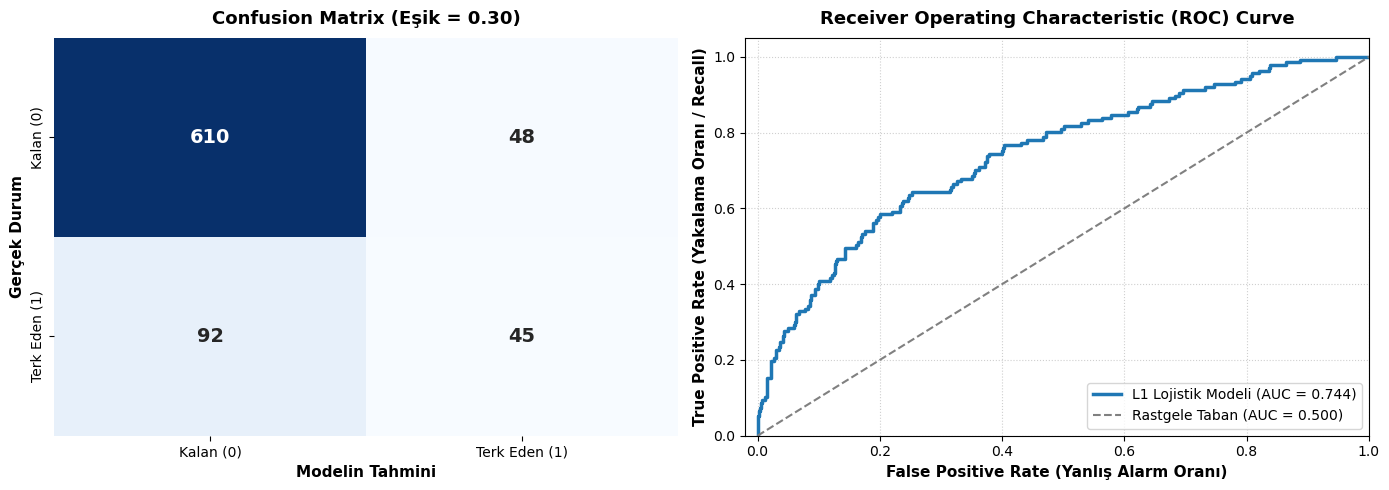

In [50]:
# ============================================================
# MODEL GÖRSELLEŞTİRME — CONFUSION MATRIX VE ROC EĞRİSİ
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# 1. Optimize modelin test olasılıkları ve 0.30 eşiğine göre tahminleri
y_prob_test_opt = best_log_model.predict_proba(X_test)[:, 1]
y_pred_test_opt = (y_prob_test_opt >= 0.30).astype(int)

# 2. Grafik Alanını Hazırlama (Yan yana 2 grafik)
plt.figure(figsize=(14, 5))

# --- SOL GRAFİK: CONFUSION MATRIX ---
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred_test_opt)

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=False,
    xticklabels=['Kalan (0)', 'Terk Eden (1)'], 
    yticklabels=['Kalan (0)', 'Terk Eden (1)'],
    annot_kws={'size': 14, 'weight': 'bold'}
)
plt.title('Confusion Matrix (Eşik = 0.30)', fontsize=13, weight='bold', pad=10)
plt.xlabel('Modelin Tahmini', fontsize=11, weight='bold')
plt.ylabel('Gerçek Durum', fontsize=11, weight='bold')

# --- SAĞ GRAFİK: ROC CURVE ---
plt.subplot(1, 2, 2)
fpr, tpr, thresholds = roc_curve(y_test, y_prob_test_opt)
roc_auc_val = auc(fpr, tpr)

plt.plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'L1 Lojistik Modeli (AUC = {roc_auc_val:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Rastgele Taban (AUC = 0.500)')
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Yanlış Alarm Oranı)', fontsize=11, weight='bold')
plt.ylabel('True Positive Rate (Yakalama Oranı / Recall)', fontsize=11, weight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=13, weight='bold', pad=10)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

**Hata Matrisi ve ROC Eğrisi Bulguları:**
* **Hata Matrisi (Eşik = 0,30):** Model, test setindeki **137 churn müşterisinin 45'ini** doğru şekilde yakaladı (**Recall: %32,8**). Churn riski verdiği **93 müşterinin 45'i** gerçekten churn oldu (**Precision: %48,4**).

* **ROC Eğrisi (AUC = 0,744):** ROC-AUC değerinin **0,744** olması, modelin churn olan ve olmayan müşterileri birbirinden ayırma konusunda rastgele tahminden daha iyi performans gösterdiğini ortaya koyuyor.


### Bölüm 2.4 — En Önemli 5 Değişken

In [51]:
# ============================================================
# BÖLÜM 2.4 — En Önemli 5 Değişken
# ============================================================

feature_names = best_log_model.named_steps['preprocessor'].get_feature_names_out()
coefficients = best_log_model.named_steps['classifier'].coef_[0]

katsayi_df = pd.DataFrame({
    'Değişken': feature_names,
    'Katsayı': coefficients
})

# Ön ekleri temizliyoruz (num__ ve cat__ kaldırılıyor)
katsayi_df['Değişken'] = (
    katsayi_df['Değişken']
    .str.replace('num__', '', regex=False)
    .str.replace('cat__', '', regex=False)
)

# 2. Şehir ve kanalları ana değişken çatısında topluyoruz
ana_degiskenler = {
    'sehir_': 'sehir',
    'musteri_tipi_': 'musteri_tipi',
    'kayit_kanali_': 'kayit_kanali'
}

def ana_degisken_bul(degisken):
    for prefix, ana_degisken in ana_degiskenler.items():
        if degisken.startswith(prefix):
            return ana_degisken
    return degisken

katsayi_df['Ana Değişken'] = katsayi_df['Değişken'].apply(ana_degisken_bul)

ana_katsayilar = (
    katsayi_df
    .assign(Mutlak_Katsayi=lambda x: x['Katsayı'].abs())
    .sort_values('Mutlak_Katsayi', ascending=False)
    .groupby('Ana Değişken', as_index=False)
    .first()
    .sort_values('Mutlak_Katsayi', ascending=False)
    .reset_index(drop=True)
)

ana_katsayilar['Etki Yönü'] = np.where(
    ana_katsayilar['Katsayı'] > 0,
    'Terk Riskini Artırıyor (+)',
    'Sadakati Artırıyor / Tutuyor (-)'
)

ana_katsayilar['Katsayı'] = ana_katsayilar['Katsayı'].round(3)

print("=== OPTİMİZE EDİLMİŞ MODELİN EN ÖNEMLİ 5 ANA DEĞİŞKENİ ===")
display(ana_katsayilar.head(5)[['Ana Değişken', 'Katsayı', 'Etki Yönü']])

=== OPTİMİZE EDİLMİŞ MODELİN EN ÖNEMLİ 5 ANA DEĞİŞKENİ ===


,Ana Değişken,Katsayı,Etki Yönü
0,recency,0.450,Terk Riskini Artırıyor (+)
1,musteri_tipi,-0.419,Sadakati Artırıyor / Tutuyor (-)
2,ort_memnuniyet,-0.324,Sadakati Artırıyor / Tutuyor (-)
3,garanti_bitmis_mi,0.243,Terk Riskini Artırıyor (+)
4,frequency,-0.199,Sadakati Artırıyor / Tutuyor (-)


### 2.4 En Önemli 5 Değişkenin Yorumlanması

L1 (Lasso) regülarizasyonu ile optimize edilen modelimizde, gürültülü ve birbirini tekrar eden değişkenler elenmiş, müşteri terkini belirleyen en kritik 5 ana davranışsal değişken ortaya çıkmıştır:

1. **`recency` (Son Servisten Geçen Gün — Katsayı: +0,450):**
   * *Tahmin Gücü & İş Anlamı:* Modelde churn ile en güçlü ilişkiye sahip değişkenlerden biri recency oldu. Pozitif katsayı, son servis üzerinden geçen süre arttıkça churn olasılığının da arttığını gösteriyor. Özellikle 150–180 günü aşan hareketsizlik, takip edilmesi gereken bir dönem olarak öne çıkıyor.

2. **`musteri_tipi` (Müşteri Türü — Katsayı: -0,419):**
   * *Tahmin Gücü & İş Anlamı:* Kurumsal müşteriler ile bireysel araç sahiplerinin servis sadakati belirgin şekilde ayrışmaktadır.

3. **`ort_memnuniyet` (Ortalama Memnuniyet Puanı — Katsayı: -0,324):**
   * *Tahmin Gücü & İş Anlamı:* Negatif katsayı, memnuniyet puanı arttıkça churn olasılığının azaldığını gösteriyor. Yani daha yüksek memnuniyet puanı veren müşterilerde terk oranı daha düşükken, düşük puan veren müşterilerde churn oranı daha yüksek görülüyor.

4. **`garanti_bitmis_mi` (Garanti Durumu — Katsayı: +0,243):**
   * *Tahmin Gücü & İş Anlamı:* Pozitif katsayı, fabrika garantisi sona eren araçlarda churn olasılığının daha yüksek olduğunu gösteriyor. Bu durum, garanti süresi sona eren müşterilerin yetkili servis dışındaki alternatiflere yönelme eğiliminin arttığına işaret ediyor.

5. **`frequency` (Ziyaret Sıklığı — Katsayı: -0,199):**
   * *Tahmin Gücü & İş Anlamı:* Negatif katsayı, geçmişte daha sık servis ziyareti yapan müşterilerde churn olasılığının daha düşük olduğunu gösteriyor. Yani düzenli servis alışkanlığı olan müşterilerin yetkili serviste kalma eğilimi daha yüksek.

### 2.5 — Modelin Temel Sınırı ve Üretim Riski

* **Temel Sınır (Zaman Kayması / Drift):** Model, tek bir gözlem dönemi ve **30 Haziran 2025** kesim tarihi üzerinden oluşturuldu. Müşteri davranışları ve ekonomik koşullar zaman içinde değişebileceği için modelin performansı ilerleyen dönemlerde düşebilir. Bu nedenle üretimde kullanıldığında model performansının düzenli olarak takip edilmesi ve gerektiğinde yeniden eğitilmesi gerekir.

* **Üretim Riski (Yanlış Pozitifler ve Maliyet):** **0,30 eşik değerinde precision %48,4** olduğu için modelin yüksek churn riski verdiği her 100 müşterinin yaklaşık 48'i gerçekten churn ederken, yaklaşık 52'si hedef dönemde churn etmemiştir. Bu nedenle bu müşterilerin tamamına doğrudan yüksek maliyetli veya indirimli kampanyalar sunulması gereksiz maliyet oluşturabilir.

* **Önerilen Operasyonel Önlem:** Model sonuçlarının doğrudan indirim kampanyası tetiklemek için kullanılmasından önce daha düşük maliyetli aksiyonlarla başlanabilir. Örneğin hatırlatma araması, memnuniyet kontrolü veya periyodik bakım bilgilendirmesi gibi iletişimler önceliklendirilebilir. Böylece model çıktısı daha kontrollü ve düşük maliyetli bir şekilde kullanılabilir.


# Bölüm 3 —  LLM ile metin analizi

## 3.1 Etiketleme

In [66]:
# 1. Boş metinleri (11 adet NaN vardı) temizliyoruz
df_feedback_temiz = df_feedback.dropna(subset=['metin']).copy()

# 2. Rastgele 200 geri bildirim seçiyoruz (Tekrarlanabilirlik için random_state=42)
df_sample_200 = df_feedback_temiz.sample(n=200, random_state=42).copy().reset_index(drop=True)

# 3. Bu 200'ün ilk 40 tanesini Altın Set olarak ayırıyoruz
df_altin_40 = df_sample_200.iloc[:40].copy().reset_index(drop=True)

print(f"Toplam temiz geri bildirim sayısı : {len(df_feedback_temiz)}")
print(f"Seçilen LLM örneklem sayısı       : {len(df_sample_200)}")
print(f"Altın Set (Referans) sayısı       : {len(df_altin_40)}")

# İlk 3 örneğe bir göz atalım
display(df_sample_200[['geri_bildirim_id', 'kanal', 'metin']].head(3))

Toplam temiz geri bildirim sayısı : 629
Seçilen LLM örneklem sayısı       : 200
Altın Set (Referans) sayısı       : 40


,geri_bildirim_id,kanal,metin
0,9503,Google Yorum,Kampanya mesajı geldi ama şubede geçerli değil...
1,9250,Anket,Bir yıldız bile fazla.
2,9562,Google Yorum,"Randevu almak kolaydı, işlem hızlı bitti. Memn..."


In [67]:
import os

os.makedirs('ciktilar', exist_ok=True)

# 200'lük örneklemi ham haliyle kaydedelim
df_sample_200.to_csv('ciktilar/orneklem_200_ham.csv', index=False, encoding='utf-8-sig')
print("200'lük ham örneklem ciktilar/orneklem_200_ham.csv dosyasına kaydedildi.")

200'lük ham örneklem ciktilar/orneklem_200_ham.csv dosyasına kaydedildi.


In [68]:
df_altin = df_sample_200.iloc[:40].copy()

df_altin = df_altin[['geri_bildirim_id', 'arac_id', 'metin']].copy()

df_altin['insan_duygu'] = ''
df_altin['insan_konular'] = ''

display(df_altin.head())

,geri_bildirim_id,arac_id,metin,insan_duygu,insan_konular
0,9503,500584,Kampanya mesajı geldi ama şubede geçerli değil...,,
1,9250,500821,Bir yıldız bile fazla.,,
2,9562,503079,"Randevu almak kolaydı, işlem hızlı bitti. Memn...",,
3,9219,503519,"Fatura tutarı verilen tekliften yüksek çıktı, ...",,
4,9543,503409,Rakip markanın servisinde aynı işlem daha ucuz...,,


In [69]:
df_altin_40 = df_sample_200.iloc[:40][
    ['geri_bildirim_id', 'arac_id', 'metin']
].copy()

df_altin_40['insan_duygu'] = ''
df_altin_40['insan_konular'] = ''

display(df_altin_40.head())


,geri_bildirim_id,arac_id,metin,insan_duygu,insan_konular
0,9503,500584,Kampanya mesajı geldi ama şubede geçerli değil...,,
1,9250,500821,Bir yıldız bile fazla.,,
2,9562,503079,"Randevu almak kolaydı, işlem hızlı bitti. Memn...",,
3,9219,503519,"Fatura tutarı verilen tekliften yüksek çıktı, ...",,
4,9543,503409,Rakip markanın servisinde aynı işlem daha ucuz...,,


In [70]:
print(df_altin_40.columns.tolist())
print(df_altin_40.iloc[0])

['geri_bildirim_id', 'arac_id', 'metin', 'insan_duygu', 'insan_konular']
geri_bildirim_id                                                 9503
arac_id                                                        500584
metin               Kampanya mesajı geldi ama şubede geçerli değil...
insan_duygu                                                          
insan_konular                                                        
Name: 0, dtype: object


In [71]:
# 40 kayıtlık boş altın set
df_altin_40.to_csv(
    'ciktilar/altin_set.csv',
    index=False,
    encoding='utf-8-sig'
)

print("40 kayıtlık boş altın seti oluşturuldu.")

40 kayıtlık boş altın seti oluşturuldu.


In [72]:
df_altin_40 = pd.read_csv(
    r'ciktilar\altin_set.csv',
    encoding='utf-8-sig'
)

print("Satır sayısı:", len(df_altin_40))
print("Dolu duygu:", df_altin_40['insan_duygu'].notna().sum())
print("Dolu konu:", df_altin_40['insan_konular'].notna().sum())

Satır sayısı: 40
Dolu duygu: 40
Dolu konu: 40


In [73]:
df_altin_40.to_csv(
    r'ciktilar\altin_set.csv',
    index=False,
    encoding='utf-8-sig'
)

print("Altın set güncel haliyle kaydedildi.")

Altın set güncel haliyle kaydedildi.


### 3.1 Örneklem ve Altın Set

Eksik metin içeren geri bildirimler çıkarıldıktan sonra kalan **629 kayıt** arasından, sonuçların tekrar üretilebilmesi için `random_state=42` kullanılarak rastgele **200 geri bildirim** seçildi. Bu 200 kayıt, LLM etiketleme örneklemini oluşturdu.

LLM çıktılarının bağımsız olarak değerlendirilebilmesi için bu örneklemden **40 kayıtlık bir altın set** ayrıldı. Bu kayıtların duygu ve konu etiketleri manuel olarak belirlendi. Duygu etiketlerinde `Olumlu`, `Olumsuz`, `Karışık` ve `Alakasız`, konu etiketlerinde ise vakada verilen sabit etiket listesi kullanıldı. **Altın set, LLM sonuçlarına bakılmadan hazırlandı.**



In [74]:
print("Duygu dağılımı:")
print(df_altin_40['insan_duygu'].value_counts())

print("\nKonu dağılımı:")
print(df_altin_40['insan_konular'].value_counts())

print("\nKullanılan duygu etiketleri:")
print(df_altin_40['insan_duygu'].unique())

print("\nİlk 10 kayıt:")
display(
    df_altin_40[
        ['geri_bildirim_id', 'metin', 'insan_duygu', 'insan_konular']
    ].head(10)
)

Duygu dağılımı:
insan_duygu
Olumsuz    19
Olumlu     17
Karışık     4
Name: count, dtype: int64

Konu dağılımı:
insan_konular
diğer                    5
iş_kalitesi              5
temizlik                 5
süre, personel           4
fiyat                    3
personel                 3
fiyat, iş_kalitesi       3
süre                     3
fiyat, diğer             2
randevu, süre            2
personel, süre           2
yedek_parça              1
personel, fiyat          1
temizlik, yedek_parça    1
Name: count, dtype: int64

Kullanılan duygu etiketleri:
['Olumsuz' 'Olumlu' 'Karışık']

İlk 10 kayıt:


,geri_bildirim_id,metin,insan_duygu,insan_konular
0,9503,Kampanya mesajı geldi ama şubede geçerli değil...,Olumsuz,"fiyat, diğer"
1,9250,Bir yıldız bile fazla.,Olumsuz,diğer
2,9562,"Randevu almak kolaydı, işlem hızlı bitti. Memn...",Olumlu,"randevu, süre"
3,9219,"Fatura tutarı verilen tekliften yüksek çıktı, ...",Olumsuz,fiyat
4,9543,Rakip markanın servisinde aynı işlem daha ucuz...,Olumsuz,fiyat
5,9513,"İkinci kez geliyorum, yine sorunsuz. Ekibe teş...",Olumlu,iş_kalitesi
6,9465,"Aracı teslim alırken içi temizlenmişti, güzel ...",Olumlu,temizlik
7,9080,"Aracı teslim alırken içi temizlenmişti, güzel ...",Olumlu,temizlik
8,9541,"Danışman bey her adımı tek tek anlattı, fiyat ...",Olumlu,personel
9,9149,İşçilik kalitesi iyiydi ama fiyatlandırma gerç...,Karışık,"fiyat, iş_kalitesi"


In [75]:
df_altin_40['insan_duygu'] = df_altin_40['insan_duygu'].str.strip()

print(df_altin_40['insan_duygu'].value_counts())

insan_duygu
Olumsuz    19
Olumlu     17
Karışık     4
Name: count, dtype: int64


Etiketleme sonrasında veri formatı kontrol edilmiş, duygu etiketlerindeki gereksiz boşluklar temizlenmiş ve konu etiketlerinin yalnızca izin verilen etiketlerden oluştuğu doğrulanmıştır.

In [76]:
izinli_konular = {
    'randevu',
    'fiyat',
    'süre',
    'personel',
    'iş_kalitesi',
    'yedek_parça',
    'temizlik',
    'diğer'
}

gecersiz_konular = []

for konular in df_altin_40['insan_konular']:
    etiketler = [x.strip() for x in konular.split(',')]
    
    for etiket in etiketler:
        if etiket not in izinli_konular:
            gecersiz_konular.append(etiket)

print("Geçersiz konu etiketi sayısı:", len(gecersiz_konular))
print("Geçersiz etiketler:", set(gecersiz_konular))

Geçersiz konu etiketi sayısı: 0
Geçersiz etiketler: set()


In [77]:
df_altin_40.to_csv(
    r'ciktilar\altin_set.csv',
    index=False,
    encoding='utf-8-sig'
)

print("Kontrol edilmiş altın set kaydedildi.")

Kontrol edilmiş altın set kaydedildi.


Etiketleme sonrasında altın set üzerinde format kontrolleri yapıldı. Duygu etiketlerindeki gereksiz boşluklar temizlendi ve konu etiketlerinin yalnızca izin verilen etiketlerden oluştuğu kontrol edildi. Kontroller sonucunda geçersiz konu etiketi bulunmadı. Son durumda **40 kaydın tamamında duygu ve konu etiketleri eksiksiz** olacak şekilde altın set kaydedildi.


In [78]:
konu_sirasi = {
    'randevu': 1,
    'fiyat': 2,
    'süre': 3,
    'personel': 4,
    'iş_kalitesi': 5,
    'yedek_parça': 6,
    'temizlik': 7,
    'diğer': 8
}

def konulari_standartlastir(konular):
    etiketler = [x.strip() for x in konular.split(',')]
    etiketler = sorted(etiketler, key=lambda x: konu_sirasi[x])
    return ', '.join(etiketler)

df_altin_40['insan_konular'] = df_altin_40['insan_konular'].apply(
    konulari_standartlastir
)

print(df_altin_40['insan_konular'].value_counts())

insan_konular
süre, personel           6
diğer                    5
iş_kalitesi              5
temizlik                 5
fiyat                    3
personel                 3
fiyat, iş_kalitesi       3
süre                     3
fiyat, diğer             2
randevu, süre            2
yedek_parça              1
fiyat, personel          1
yedek_parça, temizlik    1
Name: count, dtype: int64


In [79]:
df_altin_40.to_csv(
    r'ciktilar\altin_set.csv',
    index=False,
    encoding='utf-8-sig'
)

print("Standartlaştırılmış altın set kaydedildi.")

Standartlaştırılmış altın set kaydedildi.


## 3.2 — Kalite ölçümü

In [80]:
import pandas as pd, os

df = pd.read_csv('ciktilar/orneklem_200_ham.csv', encoding='utf-8-sig')
os.makedirs('ciktilar/gruplar', exist_ok=True)

GRUP = 25
for i in range(0, len(df), GRUP):
    parca = df.iloc[i:i+GRUP]
    satirlar = [f"{r.geri_bildirim_id} | {str(r.metin).replace(chr(10), ' ')}" for r in parca.itertuples()]
    with open(f'ciktilar/gruplar/grup_{i//GRUP+1:02d}.txt', 'w', encoding='utf-8') as f:
        f.write('\n'.join(satirlar))

print(len(df), "kayıt,", len(os.listdir('ciktilar/gruplar')), "dosya")
print(open('ciktilar/gruplar/grup_01.txt', encoding='utf-8').read()[:600])

200 kayıt, 8 dosya
9503 | Kampanya mesajı geldi ama şubede geçerli değilmiş.
9250 | Bir yıldız bile fazla.
9562 | Randevu almak kolaydı, işlem hızlı bitti. Memnun kaldım.
9219 | Fatura tutarı verilen tekliften yüksek çıktı, önceden bilgilendirilmedim.
9543 | Rakip markanın servisinde aynı işlem daha ucuzdu, orayı tercih edeceğim.
9513 | İkinci kez geliyorum, yine sorunsuz. Ekibe teşekkürler.
9465 | Aracı teslim alırken içi temizlenmişti, güzel bir detay.
9080 | Aracı teslim alırken içi temizlenmişti, güzel bir detay.
9541 | Danışman bey her adımı tek tek anlattı, fiyat konusunda da şeffaftı.
9149 | İşçilik kalit


In [90]:
# --- Gemini cevaplarını kaydetme (elle adım) ---
# API kullanılmadı. Her grup için prompt_v1 + grup_XX.txt Gemini sohbetine
# tek mesajda gönderildi, cevap `cevap` değişkenine yapıştırıldı,
# `no` grup numarasına çevrilip hücre çalıştırıldı (1..8).

import json, os

no = 1   # grup numarası (1..8)
cevap = """
"""

KLASOR = 'ciktilar/llm_ham'
os.makedirs(KLASOR, exist_ok=True)

if cevap.strip():
    veri = json.loads(cevap[cevap.index('['):cevap.rindex(']')+1])
    with open(os.path.join(KLASOR, f'grup_{no:02d}.json'), 'w', encoding='utf-8') as f:
        json.dump(veri, f, ensure_ascii=False, indent=1)
    print(f'grup_{no:02d} kaydedildi: {len(veri)} kayıt')
else:
    print('cevap boş: ham çıktılar ciktilar/llm_ham/ içinde zaten kayıtlı.')

cevap boş: ham çıktılar ciktilar/llm_ham/ içinde zaten kayıtlı.


Gemini sohbet arayüzü kullanıldı ve API kullanılmadı. Her grup için `prompt_v1` ve ilgili `grup_XX.txt` dosyası birlikte Gemini'ye gönderildi. Gemini'nin yanıtı `cevap` değişkenine eklenerek ilgili grup numarasıyla JSON formatında `ciktilar/llm_ham/` klasörüne kaydedildi. Bu işlem 8 grup için ayrı ayrı uygulandı.


In [93]:
import json, os, glob

TAM = r'ciktilar'
IZINLI_KONU = {'randevu','fiyat','süre','personel','iş_kalitesi','yedek_parça','temizlik','diğer'}
IZINLI_DUYGU = {'Olumlu','Olumsuz','Karışık','Alakasız'}

yollar = sorted(glob.glob(os.path.join(TAM, 'llm_ham', 'grup_*.json')))
print("Bulunan dosya:", len(yollar))

for yol in yollar:
    ad = os.path.basename(yol).replace('.json', '')
    beklenen = [int(l.split('|')[0]) for l in open(os.path.join(TAM, 'gruplar', f'{ad}.txt'), encoding='utf-8').read().splitlines() if l.strip()]
    veri = json.load(open(yol, encoding='utf-8'))
    gelen = [x['id'] for x in veri]
    print(ad,
          '| sayı ok:', len(gelen) == len(beklenen),
          '| id ok:', gelen == beklenen,
          '| geçersiz duygu:', [x['id'] for x in veri if x['duygu'] not in IZINLI_DUYGU],
          '| geçersiz konu:', [x['id'] for x in veri if not set(x['konular']) <= IZINLI_KONU or not x['konular']])

Bulunan dosya: 8
grup_01 | sayı ok: True | id ok: True | geçersiz duygu: [] | geçersiz konu: []
grup_02 | sayı ok: True | id ok: True | geçersiz duygu: [] | geçersiz konu: []
grup_03 | sayı ok: True | id ok: True | geçersiz duygu: [] | geçersiz konu: []
grup_04 | sayı ok: True | id ok: True | geçersiz duygu: [] | geçersiz konu: []
grup_05 | sayı ok: True | id ok: True | geçersiz duygu: [] | geçersiz konu: []
grup_06 | sayı ok: True | id ok: True | geçersiz duygu: [] | geçersiz konu: []
grup_07 | sayı ok: True | id ok: True | geçersiz duygu: [] | geçersiz konu: []
grup_08 | sayı ok: True | id ok: True | geçersiz duygu: [] | geçersiz konu: []


In [94]:
import json, glob, os
import pandas as pd

TAM = r'ciktilar'
SIRA = {'randevu':1,'fiyat':2,'süre':3,'personel':4,'iş_kalitesi':5,'yedek_parça':6,'temizlik':7,'diğer':8}

kayit = []
for yol in sorted(glob.glob(os.path.join(TAM, 'llm_ham', 'grup_*.json'))):
    kayit += json.load(open(yol, encoding='utf-8'))

llm = pd.DataFrame(kayit).rename(columns={'id':'geri_bildirim_id','duygu':'llm_duygu','konular':'llm_konular','belirsiz':'llm_belirsiz'})
llm['llm_konular'] = llm['llm_konular'].apply(lambda l: ', '.join(sorted(set(l), key=lambda x: SIRA[x])))

ham = pd.read_csv(os.path.join(TAM, 'orneklem_200_ham.csv'), encoding='utf-8-sig')
cikti = ham[['geri_bildirim_id','arac_id','metin']].merge(llm, on='geri_bildirim_id', how='left', validate='1:1')

print("Satır:", len(cikti), "| eksik etiket:", cikti['llm_duygu'].isna().sum())
cikti.to_csv(os.path.join(TAM, 'llm_etiketleri.csv'), index=False, encoding='utf-8-sig')
print(cikti['llm_duygu'].value_counts())

Satır: 200 | eksik etiket: 0
llm_duygu
Olumsuz     86
Olumlu      86
Karışık     22
Alakasız     6
Name: count, dtype: int64


### Altın Set ile Karşılaştırma

In [95]:
import pandas as pd, os
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score

TAM = r'ciktilar'
KONULAR = ['randevu','fiyat','süre','personel','iş_kalitesi','yedek_parça','temizlik','diğer']

altin = pd.read_csv(os.path.join(TAM, 'altin_set.csv'), encoding='utf-8-sig')[['geri_bildirim_id','metin','insan_duygu','insan_konular']]
llm = pd.read_csv(os.path.join(TAM, 'llm_etiketleri.csv'), encoding='utf-8-sig')[['geri_bildirim_id','llm_duygu','llm_konular']]
d = altin.merge(llm, on='geri_bildirim_id', validate='1:1')
print("Karşılaştırılan kayıt:", len(d))

# --- DUYGU ---
print("\nDuygu doğruluğu:", round((d.insan_duygu == d.llm_duygu).mean(), 3))
print("Cohen kappa:", round(cohen_kappa_score(d.insan_duygu, d.llm_duygu), 3))
etk = ['Olumlu','Olumsuz','Karışık','Alakasız']
print(pd.DataFrame(confusion_matrix(d.insan_duygu, d.llm_duygu, labels=etk), index='insan_'+pd.Index(etk), columns='llm_'+pd.Index(etk)))
print(classification_report(d.insan_duygu, d.llm_duygu, labels=etk, zero_division=0))

# --- KONULAR ---
def kume(s): return {x.strip() for x in str(s).split(',') if x.strip()}
d['i'] = d.insan_konular.apply(kume); d['l'] = d.llm_konular.apply(kume)
print("Konu tam eşleşme:", round((d.i == d.l).mean(), 3))
print("Konu Jaccard ort.:", round((d.apply(lambda r: len(r.i & r.l) / len(r.i | r.l), axis=1)).mean(), 3))
rows = []
for k in KONULAR:
    tp = sum((k in r.i) and (k in r.l) for r in d.itertuples())
    fp = sum((k not in r.i) and (k in r.l) for r in d.itertuples())
    fn = sum((k in r.i) and (k not in r.l) for r in d.itertuples())
    rows.append((k, tp, fp, fn))
print(pd.DataFrame(rows, columns=['konu','tp','fp (LLM fazla)','fn (LLM eksik)']))

# --- FARKLI OLANLAR ---
pd.set_option('display.max_colwidth', None)
print("\nDuygu farklı olanlar:")
print(d[d.insan_duygu != d.llm_duygu][['geri_bildirim_id','metin','insan_duygu','llm_duygu']].to_string(index=False))
print("\nKonu farklı olanlar:")
print(d[d.i != d.l][['geri_bildirim_id','metin','insan_konular','llm_konular']].to_string(index=False))

Karşılaştırılan kayıt: 40

Duygu doğruluğu: 0.975
Cohen kappa: 0.956
                llm_Olumlu  llm_Olumsuz  llm_Karışık  llm_Alakasız
insan_Olumlu            17            0            0             0
insan_Olumsuz            0           19            0             0
insan_Karışık            0            1            3             0
insan_Alakasız           0            0            0             0
              precision    recall  f1-score   support

      Olumlu       1.00      1.00      1.00        17
     Olumsuz       0.95      1.00      0.97        19
     Karışık       1.00      0.75      0.86         4
    Alakasız       0.00      0.00      0.00         0

   micro avg       0.97      0.97      0.97        40
   macro avg       0.74      0.69      0.71        40
weighted avg       0.98      0.97      0.97        40

Konu tam eşleşme: 0.625
Konu Jaccard ort.: 0.758
          konu  tp  fp (LLM fazla)  fn (LLM eksik)
0      randevu   2               2               0
1        f

### Sistematik Hatalar ve Örnekler

In [96]:
import pandas as pd, os
TAM = r'ciktilar'
l = pd.read_csv(os.path.join(TAM, 'llm_etiketleri.csv'), encoding='utf-8-sig')
pd.set_option('display.max_colwidth', None)
print("belirsiz=True sayısı:", l.llm_belirsiz.sum())
print(l[l.llm_duygu == 'Alakasız'][['geri_bildirim_id','metin','llm_konular']].to_string(index=False))
print("Tekrarlayan metin oranı (200'de):", round(l.metin.duplicated(keep=False).mean(), 2), "| benzersiz metin:", l.metin.nunique())

belirsiz=True sayısı: 10
 geri_bildirim_id metin llm_konular
             9031     ?       diğer
             9218     -       diğer
             9328     -       diğer
             9275     ?       diğer
             9376     -       diğer
             9535     ?       diğer
Tekrarlayan metin oranı (200'de): 1.0 | benzersiz metin: 35


### Tutarlılık Analizi

In [97]:
import pandas as pd, os
TAM = r'ciktilar'
l = pd.read_csv(os.path.join(TAM, 'llm_etiketleri.csv'), encoding='utf-8-sig')
pd.set_option('display.max_colwidth', None)

l['etiket'] = l.llm_duygu + ' | ' + l.llm_konular
g = l.groupby('metin').agg(adet=('etiket','size'), farkli_etiket=('etiket','nunique'))
print("Aynı metne farklı etiket verilen metin sayısı:", (g.farkli_etiket > 1).sum(), "/", len(g))
print(g[g.farkli_etiket > 1])

print("\nbelirsiz=True ve Alakasız olmayanlar:")
print(l[(l.llm_belirsiz) & (l.llm_duygu != 'Alakasız')][['geri_bildirim_id','metin','llm_duygu','llm_konular']].to_string(index=False))

Aynı metne farklı etiket verilen metin sayısı: 9 / 35
                                                                                      adet  \
metin                                                                                        
Fatura tutarı verilen tekliften yüksek çıktı, önceden bilgilendirilmedim.                8   
Harika bir deneyimdi, sadece üç hafta bekledim.                                          5   
Hiç de memnun kalmadım denemez, işlerini biliyorlar.                                     4   
Kötü diyemem ama bir daha gelir miyim bilmiyorum.                                        5   
Mükemmel değildi ama beklentimin altında da kalmadı.                                     5   
Servis temizdi ve ekip güler yüzlüydü, yalnızca yedek parça beklemesi can sıkıcıydı.     2   
Telefonla kimseye ulaşamıyorum, çağrı merkezi sürekli meşgul.                            6   
Ödeme sırasında POS çalışmadı, nakit aramak zorunda kaldım.                              6   
İkinci

In [98]:
for m, grp in l.groupby('metin'):
    if grp.etiket.nunique() > 1:
        print(m[:50], '| duygu:', grp.llm_duygu.nunique(), '| konu:', grp.llm_konular.nunique())

Fatura tutarı verilen tekliften yüksek çıktı, önce | duygu: 1 | konu: 2
Harika bir deneyimdi, sadece üç hafta bekledim. | duygu: 2 | konu: 1
Hiç de memnun kalmadım denemez, işlerini biliyorla | duygu: 1 | konu: 2
Kötü diyemem ama bir daha gelir miyim bilmiyorum. | duygu: 2 | konu: 1
Mükemmel değildi ama beklentimin altında da kalmad | duygu: 2 | konu: 1
Servis temizdi ve ekip güler yüzlüydü, yalnızca ye | duygu: 1 | konu: 2
Telefonla kimseye ulaşamıyorum, çağrı merkezi süre | duygu: 1 | konu: 2
Ödeme sırasında POS çalışmadı, nakit aramak zorund | duygu: 1 | konu: 2
İkinci kez geliyorum, yine sorunsuz. Ekibe teşekkü | duygu: 1 | konu: 2


In [100]:
   print(altin.metin.nunique(), "benzersiz metin /", len(altin), "kayıt")
   print(altin.metin.str.contains("Fena değildi|Kötü diyemem|Mükemmel değildi").sum())

22 benzersiz metin / 40 kayıt
0


## 3.2 Kalite Ölçümü ve Değerlendirme

**Yöntem.** 200 kayıtlık örneklemin ilk 40 kaydı, LLM sonuçları görülmeden elle etiketlendi ve altın set olarak kullanıldı. Etiketleme Gemini sohbet arayüzleri üzerinden, API kullanılmadan ve 25'er kayıttan oluşan 8 grup halinde yapıldı. Tüm gruplarda aynı `prompt_v1` kullanıldı ve sonuçlar görüldükten sonra istem değiştirilmedi. İlk 4 grup (1-4) Gemini Flash 3.7, son 4 grup (5-8) Gemini Flash 3.6 ile etiketlendi. Tüm gruplarda aynı istem kullanıldı ve sonuçlara bakıp değiştirilmedi. Temperature ayarı kontrol edilemediği için sonuçlar tek çalıştırmaya dayanmaktadır.

**Sonuçlar (n=40, 22 benzersiz metin)**

| Ölçü                    | Sonuç                              |
| ----------------------- | ---------------------------------- |
| Duygu doğruluğu         | %97,5 (39/40), Cohen's kappa 0,956 |
| Konu tam eşleşme        | %62,5                              |
| Konu Jaccard ortalaması | 0,758                              |

**Genel değerlendirme.** Duygu etiketlemesinde oldukça başarılı sonuç alındı. Konu etiketlemesindeki başarı ise daha düşük kaldı, ancak burada sorunun bir kısmı model kaynaklı değil. Altın set hazırlanırken aynı metne bazı durumlarda farklı konu etiketleri verilmiş. Örneğin *"Ekibe teşekkürler"* ifadesinde farklı etiketler kullanılmış. Bazı örneklerde ise benim etiketleme kuralım ile istemdeki tanım tam olarak örtüşmemiş. Örneğin bir kampanya mesajı için ben `fiyat, diğer` etiketlerini kullanırken, istemde yalnızca `fiyat` olarak tanımlanmış. Bu nedenle %62,5'lik sonucu yalnızca model performansı olarak değerlendirmemek gerekiyor.

Altın set, model sonuçları görülmeden hazırlandığı için sonradan Gemini'nin çıktısına göre değiştirilmedi. Böylece değerlendirme sonuçlara göre şekillendirilmemiş oldu.

**Modelin yanıldığı yerler:**
1. *Nötre yakın cümleler.* Şemada "Nötr" olmadığı için model aynı metne Olumlu, Karışık ya da Olumsuz diyebiliyor. "Belirsiz" işaretlediği 10 kaydın hepsi bu tipteydi.
2. *Anahtar kelimeye takılma sorunu.* "Randevu saatinde gittim ama iki saat bekledim…" cümlesine, asıl sorun bekleme olduğu halde `randevu` da eklendi (2 kayıt, tek metin, güçlü bir örüntü sayılmaz).

Ayrıca 35 benzersiz metnin 9'unda model aynı metne farklı etiket verdi, yani tam tutarlı değil. Gruplarda model sürümü ve arayüz sabit tutulmadığı için bu farkın kaynağı (istem mi, model sürümü mü) ayrıştırılamadı. Altın sette `Alakasız` örneği olmadığından bu sınıf ölçülemedi.

## 3.3 Aksiyon önerisi


In [107]:
import os
import pandas as pd

pd.set_option('display.max_colwidth', None)

TAM = r'ciktilar'
ESIK = 0.30   

# 1) Tüm modelleme popülasyonu için risk skoru
risk = df_analiz.loc[X.index, ['musteri_id', 'churn', 'recency', 'frequency', 'ort_memnuniyet']].copy()
risk['risk_skoru'] = best_log_model.predict_proba(X)[:, 1]
risk['bolum'] = 'train'
risk.loc[X_val.index, 'bolum'] = 'val'
risk.loc[X_test.index, 'bolum'] = 'test'
print("Risk tablosu:", risk.shape, "| tekil müşteri:", risk.musteri_id.nunique())

# 2) LLM etiketleri
llm_et = pd.read_csv(os.path.join(TAM, 'llm_etiketleri.csv'), encoding='utf-8-sig')
llm_et = llm_et[['geri_bildirim_id', 'llm_duygu', 'llm_konular', 'llm_belirsiz']]

zincir = (df_sample_200[['geri_bildirim_id', 'arac_id', 'metin']]
          .merge(llm_et, on='geri_bildirim_id', how='left', validate='1:1')
          .merge(df_araclar[['arac_id', 'musteri_id']], on='arac_id', how='left')
          .merge(risk, on='musteri_id', how='left'))

print("Toplam geri bildirim                :", len(zincir))
print("Müşteriye bağlanamayan              :", zincir.musteri_id.isna().sum())
print("Risk skoru olmayan (popülasyon dışı):", zincir.risk_skoru.isna().sum())

# 3) Yüksek risk + olumsuz geri bildirim
aday = zincir[(zincir.risk_skoru >= ESIK) & (zincir.llm_duygu == 'Olumsuz')].copy()
print("\nAday sayısı:", len(aday), "| benzersiz müşteri:", aday.musteri_id.nunique(),
      "| benzersiz metin:", aday.metin.nunique())
print(aday.bolum.value_counts().to_string())

# 4) Tekrarı at, riske göre sırala
liste = (aday.sort_values('risk_skoru', ascending=False)
             .drop_duplicates(subset=['musteri_id', 'metin']))
print("\nİlk 20 aday:")
print(liste[['geri_bildirim_id', 'musteri_id', 'metin', 'llm_konular',
             'risk_skoru', 'recency', 'ort_memnuniyet', 'churn', 'bolum']]
      .head(20).round(3).to_string(index=False))

Risk tablosu: (3971, 7) | tekil müşteri: 3971
Toplam geri bildirim                : 200
Müşteriye bağlanamayan              : 0
Risk skoru olmayan (popülasyon dışı): 5

Aday sayısı: 6 | benzersiz müşteri: 6 | benzersiz metin: 6
bolum
train    4
test     1
val      1

İlk 20 aday:
 geri_bildirim_id  musteri_id                                                                     metin       llm_konular  risk_skoru  recency  ort_memnuniyet  churn bolum
             9320      103903                           Harika bir deneyimdi, sadece üç hafta bekledim.              süre       0.602    408.0           3.333    1.0 train
             9226      103816               Ödeme sırasında POS çalışmadı, nakit aramak zorunda kaldım.             fiyat       0.461    289.0           3.000    1.0 train
             9144      103167     Yedek parça iki hafta bekledi, bu süre boyunca aracım serviste kaldı. süre, yedek_parça       0.435    316.0           3.750    0.0 train
             9278      100796 F

In [111]:
import os
import pandas as pd
from IPython.display import display, HTML

TAM = r'ciktilar'
ESIK = 0.30

# 9226: POS arızası metni, LLM 'fiyat' etiketi hatalı (ödeme altyapısı sorunu), aday listesinden elle çıkarıldı
HARIC_ID = [9226]

# 1) Risk skoru
risk = df_analiz.loc[X.index, ['musteri_id', 'churn', 'recency', 'frequency', 'ort_memnuniyet']].copy()
risk['risk_skoru'] = best_log_model.predict_proba(X)[:, 1]
risk['bolum'] = 'train'
risk.loc[X_val.index, 'bolum'] = 'val'
risk.loc[X_test.index, 'bolum'] = 'test'

# 2) Zincir
llm_et = pd.read_csv(os.path.join(TAM, 'llm_etiketleri.csv'), encoding='utf-8-sig')
llm_et = llm_et[['geri_bildirim_id', 'llm_duygu', 'llm_konular', 'llm_belirsiz']]

zincir = (df_sample_200[['geri_bildirim_id', 'arac_id', 'metin']]
          .merge(llm_et, on='geri_bildirim_id', how='left', validate='1:1')
          .merge(df_araclar[['arac_id', 'musteri_id']], on='arac_id', how='left')
          .merge(risk, on='musteri_id', how='left'))

# 3) Özet tablosu
ozet = pd.DataFrame({
    'Gösterge': ['Toplam geri bildirim', 'Müşteriye bağlanamayan',
                 'Risk skoru olmayan (popülasyon dışı)'],
    'Sayı': [len(zincir), int(zincir.musteri_id.isna().sum()),
             int(zincir.risk_skoru.isna().sum())]
})

# 4) Adaylar
aday = zincir[(zincir.risk_skoru >= ESIK) & (zincir.llm_duygu == 'Olumsuz')].copy()
liste = (aday.sort_values('risk_skoru', ascending=False)
             .drop_duplicates(subset=['musteri_id', 'metin']))

n_ham = len(liste)
liste = liste[~liste['geri_bildirim_id'].isin(HARIC_ID)].reset_index(drop=True)   # elle çıkarma burada
liste.index = liste.index + 1

tablo = liste[['geri_bildirim_id', 'musteri_id', 'metin', 'llm_konular',
               'risk_skoru', 'recency', 'ort_memnuniyet', 'bolum']].rename(columns={
    'geri_bildirim_id': 'Geri Bildirim ID', 'musteri_id': 'Müşteri ID',
    'metin': 'Metin', 'llm_konular': 'LLM Konu',
    'risk_skoru': 'Risk Skoru', 'recency': 'Recency (gün)',
    'ort_memnuniyet': 'Ort. Memnuniyet', 'bolum': 'Bölüm'})

stil = (tablo.style
        .format({'Risk Skoru': '{:.3f}', 'Recency (gün)': '{:.0f}', 'Ort. Memnuniyet': '{:.2f}'})
        .set_properties(subset=['Metin'], **{'white-space': 'normal', 'min-width': '320px', 'text-align': 'left'})
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left'), ('background-color', '#f0f2f6')]}])
        .bar(subset=['Risk Skoru'], color='#f4a6a6', vmin=0, vmax=1))

display(HTML("<h4>Bağlantı özeti</h4>"))
display(ozet.style.hide(axis='index'))
display(HTML(f"<h4>Aday müşteriler (risk ≥ {ESIK} ve LLM duygu = Olumsuz) — {n_ham} aday, {n_ham - len(liste)} elle çıkarıldı (ID: {HARIC_ID}), {len(liste)} kişi</h4>"))
display(stil)
display(HTML("<h4>Bölüm dağılımı</h4>"))
display(liste['bolum'].value_counts().rename_axis('Bölüm').reset_index(name='Adet').style.hide(axis='index'))

Gösterge,Sayı
Toplam geri bildirim,200
Müşteriye bağlanamayan,0
Risk skoru olmayan (popülasyon dışı),5


,Geri Bildirim ID,Müşteri ID,Metin,LLM Konu,Risk Skoru,Recency (gün),Ort. Memnuniyet,Bölüm
1,9320,103903,"Harika bir deneyimdi, sadece üç hafta bekledim.",süre,0.602,408,3.33,train
2,9144,103167,"Yedek parça iki hafta bekledi, bu süre boyunca aracım serviste kaldı.","süre, yedek_parça",0.435,316,3.75,train
3,9278,100796,"Fatura tutarı verilen tekliften yüksek çıktı, önceden bilgilendirilmedim.",fiyat,0.425,304,3.67,val
4,9383,102827,"Telefonla kimseye ulaşamıyorum, çağrı merkezi sürekli meşgul.",personel,0.406,301,4.00,test
5,9543,102990,"Rakip markanın servisinde aynı işlem daha ucuzdu, orayı tercih edeceğim.",fiyat,0.367,358,4.00,train


Bölüm,Adet
train,3
val,1
test,1


## 3.3 Aksiyon Önerisi

**Seçim.** Risk skoru ≥ 0,30 ve LLM duygusu "Olumsuz" olan 6 aday çıktı. Bunlardan 1'i (9226, POS arızası) LLM'in `fiyat` etiketi hatalı olduğu için elle çıkarıldı, 5 aday kaldı. `churn` bilgisine bakılmadan, farklı konulardan 3 müşteri seçildi: 100796 (val), 102827 (test), 102990 (train).

**Yöntem.** Gemini 3.1 Pro (Google AI Studio), API'siz, tek çalıştırma. İstem: `prompt_aksiyon_v1` (Bölüm 5).

| Müşteri | Aksiyon önerisi |
|---|---|
| 100796 | Müşteriyi arayıp dinleyin, yaşanan durum için özür dileyerek süreci kontrol edip kendisine geri dönün. |
| 102827 | Müşteriyi arayarak yaşanan iletişim sorunu için özür dileyin ve durumu yöneticiye iletin. |
| 102990 | Müşteriyi arayıp dinleyin, servis standartlarımız hakkında bilgilendirme yaparak durumu yöneticiye iletin. |

Üç önerinin hiçbirinde indirim, kampanya ya da şirketin sunmadığı bir teklif yok. Ancak öneriler genel kaldı: 102990'da müşteri rakibin daha ucuz olduğunu söylüyor, öneri de ise fiyata hiç değinmiyor.

**Modelin "%50 indirim" gibi şirketin sunmadığı bir kampanya önermesini nasıl engellerim?**

LLM'in şirketin sunmadığı bir kampanya veya indirim önermesini önlemek için, modelin verebileceği cevaplar baştan belirlenebilir. Örneğin yalnızca müşteriyi arama, sorunu dinleme, özür dileme, süreci kontrol etme ve gerekirse yöneticiye iletme gibi mevcut aksiyonlardan birini önermesi istenebilir. İndirim, hediye veya iade gibi şirket tarafından tanımlanmamış çözümler ise istemde açıkça yasaklanmalıdır.

İstem tek başına garanti vermediği için, öneriler müşteriye iletilmeden önce de kontrol edilmelidir. Çıktıyı basit bir kelime taramasından (indirim, kampanya, iade, %, TL) geçirmek ve bir temsilcinin göz atmasını sağlamak bu kontrol için yeterlidir.


In [116]:
# README için kütüphane kontrolu

In [117]:
import json, re

NB = '0-0Analiz.ipynb' 
nb = json.load(open(NB, encoding='utf-8'))
bulunan = set()
for h in nb['cells']:
    if h['cell_type'] == 'code':
        for satir in ''.join(h['source']).splitlines():
            m = re.match(r'\s*(?:import|from)\s+([A-Za-z_][\w]*)', satir)
            if m:
                bulunan.add(m.group(1))
print(sorted(bulunan))

['IPython', 'catboost', 'json', 'matplotlib', 'numpy', 'os', 'pandas', 'seaborn', 'sklearn', 'sys']


In [118]:
import sys, importlib.metadata as md

paketler = ['pandas', 'numpy', 'scikit-learn', 'catboost', 'matplotlib', 'seaborn', 'ipython', 'notebook', 'jupyterlab']
print("Python:", sys.version.split()[0])
for p in paketler:
    try:
        print(f"{p}=={md.version(p)}")
    except md.PackageNotFoundError:
        print(f"{p}: kurulu değil")

Python: 3.11.5
pandas==2.0.3
numpy==1.26.4
scikit-learn==1.3.0
catboost==1.2.3
matplotlib==3.7.2
seaborn==0.12.2
ipython==8.15.0
notebook==6.5.4
jupyterlab==3.6.3
